## **SOLVER PARA ANÁLISE DINÂMICA DE ESTRUTURA RETICULADA SUBMETIDA A SISMO**
##### VERSÃO 1.0
#### **AUTORES: EDUARDO TORRI E RICHARD GOSSLER**
#### **ORIENTADORA: PROF. LETÍCIA FLECK FADEL MIGUEL, DR. ENG.**
##### UFRGS - Programa de Pós-Graduação em Engenharia Civil (PPGEC)
##### PEC00141: Fundamentos de Métodos Numéricos e Mecânica Das Estruturas Computacional

In [1]:
# Importando módulos essenciais para análise matemática, manipulação de dados e visualização
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows', None)
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D # Para legendas customizadas nos gráficos

# Importando módulos avançados do SciPy para otimização topológica (RCM) e autovalores
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee
from scipy.linalg import eigh

### DADOS DE ENTRADA E UNIDADES ESPERADAS (Planilha Excel)

Neste solver, nós adotamos o Sistema Internacional (SI) como base estrutural. Para garantirmos a consistência da Matriz de Rigidez ($K = \frac{EA}{L}$ resultando em $N/m$), os dados inseridos na planilha `DADOS_DE_ENTRADA.xlsx` devem obedecer rigorosamente às seguintes unidades:

**Aba 'Nós':**
- `X`, `Y`: Coordenadas do nó em **Metros (m)**.
- `RX`, `RY`: Condições de contorno (Apoios). Usar **1** para deslocamento restrito e **0** (ou vazio) para livre.
- `FX`, `FY`: Cargas nodais concentradas em **Newtons (N)**. *(Nota: O solver converte para kN apenas na visualização gráfica).*

**Aba 'Barras':**
- `NI`, `NF`: Número (ID) do nó inicial e final da barra.
- `A`: Área da seção transversal da barra em **Metros quadrados (m²)**.
- `E`: Módulo de Elasticidade Longitudinal (Módulo de Young) em **Pascal (Pa ou N/m²)**.

In [2]:
# Importação dos dados da planilha
nos = pd.read_excel('DADOS_DE_ENTRADA.xlsx', sheet_name='Nós')
barras = pd.read_excel('DADOS_DE_ENTRADA.xlsx', sheet_name='Barras')

# Ajustando índices de nós e barras para Base 1 (Padrão de Engenharia)
nos.index += 1
barras.index += 1

# Substitui valores em branco (NaN) gerados pelo Excel por zero para evitar quebra no cálculo
nos = nos.fillna(0)

### OTIMIZAÇÃO TOPOLÓGICA: ALGORITMO REVERSE CUTHILL-MCKEE (RCM) COM REORDENAÇÃO DE BARRAS

Para garantirmos a máxima eficiência computacional e a organização lógica dos resultados analíticos (especialmente nas etapas de resolução de sistemas lineares e Fatoração de Cholesky inerentes à análise dinâmica), nós submetemos os dados de entrada a dois processos distintos e complementares: um de caráter matricial e outro de caráter espacial.

**1. Reorganização Nodal via Algoritmo Reverse Cuthill-McKee (RCM)**
O primeiro processo atua na conectividade dos nós e visa otimizar estritamente o processamento numérico. Inicialmente, modelamos a treliça como um grafo não-direcionado, onde os nós representam os vértices e as barras representam as arestas. Extraímos essa conectividade das colunas `NI` e `NF` e a mapeamos em uma Matriz de Adjacência simétrica esparsa (formato CSR).

Sobre esta matriz, nós aplicamos o algoritmo heurístico de *Reverse Cuthill-McKee* (RCM). O nosso objetivo com o RCM é encontrar uma nova permutação para a numeração (IDs) dos nós que minimize a meia-largura de banda (*bandwidth*) da Matriz de Rigidez Global. O algoritmo aloca os elementos não-nulos o mais próximo possível da diagonal principal. Em termos de custo computacional, isso reduz drasticamente o alocamento de memória RAM e acelera as operações de decomposição algébrica de $\mathcal{O}(n^3)$ para $\mathcal{O}(nb^2)$, onde $b$ representa a nova largura de banda otimizada.

**2. Reordenação Geométrica e Visual das Barras**
Enquanto a otimização do RCM atende a um rigoroso requisito de performance da máquina, nós focamos o segundo processo integralmente na rastreabilidade e na interpretabilidade para quem analisa o projeto. O lançamento manual de geometria em planilhas frequentemente resulta em numerações caóticas, dificultando a leitura dos diagramas.

Para solucionar essa entropia visual, nós reordenamos as barras com base em sua localização espacial exata. Calculamos o ponto médio matemático de cada elemento (`MID_X` e `MID_Y`) e classificamos a matriz de barras em ordem crescente: de baixo para cima e, secundariamente, da esquerda para a direita. Esse ordenamento contínuo garante que os diagramas de esforços e tensões sigam uma progressão geométrica lógica e previsível.

In [3]:
# Limpeza de segurança (Evita erros de digitação vazios no Excel)
barras = barras.dropna(subset=['NI', 'NF']).copy()
barras['NI'] = barras['NI'].astype(int)
barras['NF'] = barras['NF'].astype(int)

# Montagem da Matriz de Adjacência para representação do Grafo da Treliça
N = len(nos)
linhas = barras['NI'].values - 1
colunas = barras['NF'].values - 1
dados = np.ones(len(barras))

grafo = csr_matrix((dados, (linhas, colunas)), shape=(N, N))
grafo_simetrico = grafo + grafo.T

# Aplicação do algoritmo Reverse Cuthill-McKee para redução da largura de banda
permutacao_rcm = reverse_cuthill_mckee(grafo_simetrico, symmetric_mode=True)

# Mapeamento Dicionário: Nó antigo -> Nó novo otimizado
mapa_nos = {no_antigo + 1: novo_id + 1 for novo_id, no_antigo in enumerate(permutacao_rcm)}
print("Mapeamento do RCM gerado (Nó Antigo -> Novo ID):")
print(mapa_nos)

# Atualizando matriz de barras com a nova topologia nodal
barras['NI'] = barras['NI'].map(mapa_nos).astype(int)
barras['NF'] = barras['NF'].map(mapa_nos).astype(int)

# Atualizando matriz de nós com os novos IDs
nos['NOVO_ID'] = nos.index.map(mapa_nos).astype(int)
nos = nos.sort_values('NOVO_ID')
nos = nos.set_index('NOVO_ID')
nos.index.name = None

# Otimização visual da numeração de barras (ordena de baixo para cima, da esquerda para direita)
X_ni, X_nf = nos.loc[barras['NI'], 'X'].values, nos.loc[barras['NF'], 'X'].values
Y_ni, Y_nf = nos.loc[barras['NI'], 'Y'].values, nos.loc[barras['NF'], 'Y'].values

barras['MID_X'] = (X_ni + X_nf) / 2.0
barras['MID_Y'] = (Y_ni + Y_nf) / 2.0
barras = barras.sort_values(by=['MID_Y', 'MID_X'], ascending=[True, True])

# Mapeamento das barras (mantendo rastreabilidade)
mapa_barras = {id_antigo: novo_id + 1 for novo_id, id_antigo in enumerate(barras.index)}
print("\nMapeamento das Barras gerado (ID Antigo -> Novo ID):")
print(mapa_barras)

barras = barras.reset_index(drop=True)
barras.index += 1
barras = barras.drop(columns=['MID_X', 'MID_Y'])
print("\nEstrutura topológica reordenada e pronta para cálculo.")

Mapeamento do RCM gerado (Nó Antigo -> Novo ID):
{np.int32(31): 1, np.int32(36): 2, np.int32(32): 3, np.int32(29): 4, np.int32(35): 5, np.int32(33): 6, np.int32(34): 7, np.int32(30): 8, np.int32(21): 9, np.int32(27): 10, np.int32(28): 11, np.int32(26): 12, np.int32(22): 13, np.int32(19): 14, np.int32(11): 15, np.int32(2): 16, np.int32(1): 17, np.int32(23): 18, np.int32(25): 19, np.int32(24): 20, np.int32(20): 21, np.int32(17): 22, np.int32(12): 23, np.int32(9): 24, np.int32(4): 25, np.int32(3): 26, np.int32(18): 27, np.int32(13): 28, np.int32(7): 29, np.int32(6): 30, np.int32(5): 31, np.int32(14): 32, np.int32(8): 33, np.int32(15): 34, np.int32(10): 35, np.int32(16): 36}

Mapeamento das Barras gerado (ID Antigo -> Novo ID):
{9: 1, 1: 2, 14: 3, 15: 4, 5: 5, 10: 6, 2: 7, 17: 8, 16: 9, 6: 10, 11: 11, 3: 12, 18: 13, 19: 14, 7: 15, 12: 16, 24: 17, 29: 18, 26: 19, 4: 20, 20: 21, 8: 22, 32: 23, 23: 24, 25: 25, 31: 26, 30: 27, 21: 28, 22: 29, 13: 30, 27: 31, 28: 32, 33: 33, 39: 34, 35: 35, 37:

In [4]:
# Visualização da tabela de Nós otimizada
display(nos)

,X,Y,RX,RY,FX,FY
1,-5.25,30.0,0,0,0,-8000
2,9.75,30.0,0,0,0,-8000
3,-2.25,30.0,0,0,0,0
4,-2.25,28.5,0,0,0,0
5,6.75,30.0,0,0,0,0
6,0.75,30.0,0,0,0,0
7,3.75,30.0,0,0,0,0
8,6.75,28.5,0,0,0,0
9,-5.25,24.0,0,0,0,-8000
10,0.75,27.0,0,0,0,0


In [5]:
# Visualização da tabela de Barras otimizada
display(barras)

,NI,NF,A,E,RHO
1,17,16,0.003,200000000000,7850
2,17,26,0.003,200000000000,7850
3,17,25,0.003,200000000000,7850
4,16,26,0.003,200000000000,7850
5,16,25,0.003,200000000000,7850
6,26,25,0.003,200000000000,7850
7,26,31,0.003,200000000000,7850
8,26,30,0.003,200000000000,7850
9,25,31,0.003,200000000000,7850
10,25,30,0.003,200000000000,7850


### DESENHANDO A ESTRUTURA ORIGINAL

Utilizamos essa visualização preliminar como uma etapa prática de **validação visual do modelo físico** antes de montarmos as matrizes numéricas. Esta rotina traduz os dados tabulares, permitindo conferirmos a geometria, a conectividade e as condições de contorno inseridas no Excel.

Para garantir clareza geométrica em projetos de qualquer porte, nós implementamos as seguintes lógicas:

* **Escalonamento Dinâmico:** Calculamos uma dimensão de referência (`dim_ref`) a partir da envoltória total da estrutura. Esse fator ajusta automaticamente o tamanho das setas de carga e textos, garantindo legibilidade.
* **Plotagem Topológica:** Iteramos sobre as tabelas para desenhar as barras (linhas), os nós (rótulas), os IDs reordenados e as restrições de apoio (triângulos).
* **Vetorização de Cargas:** Convertamos e exibimos as forças estáticas de Newtons (N) para kilonewtons (kN) diretamente no gráfico para facilitar a leitura.
* **Fidelidade Espacial:** Travamos o gráfico em uma proporção isométrica (`aspect='equal'`), garantindo que inclinações e comprimentos correspondam à realidade física, sem distorções entre X e Y.

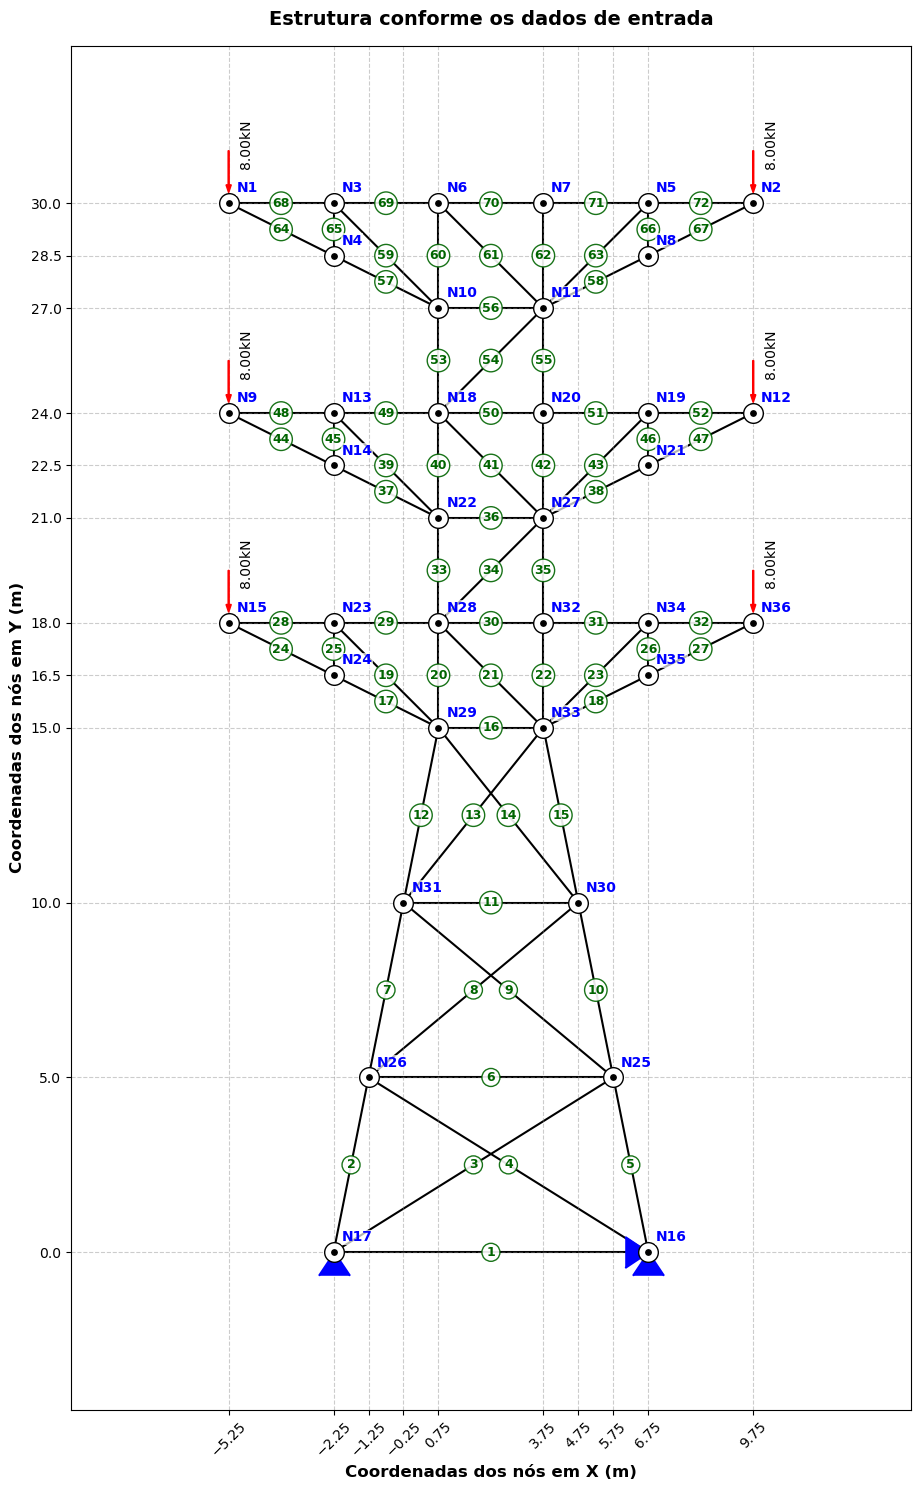

In [6]:
plt.figure(1, figsize=(15, 15))
plt.title('Estrutura conforme os dados de entrada', fontsize=14, weight='bold', pad=15)

# Dimensão de referência para padronizar tamanho dinâmico de setas e textos
dim_ref = max(nos['X'].max() - nos['X'].min(), nos['Y'].max() - nos['Y'].min())
if dim_ref == 0: dim_ref = 1.0
off = dim_ref * 0.05

# Plotando as barras
for row in barras.itertuples(): 
    xi, yi = nos.loc[row.NI, ['X', 'Y']]
    xf, yf = nos.loc[row.NF, ['X', 'Y']]
    plt.plot([xi, xf], [yi, yf], color='black', zorder=1)
    
    # Identificação central da barra
    mid_x, mid_y = (xi + xf) / 2, (yi + yf) / 2
    plt.text(mid_x, mid_y, str(row.Index), color='darkgreen', fontsize=9, weight='bold',
             ha='center', va='center', zorder=6,
             bbox=dict(facecolor='white', edgecolor='darkgreen', boxstyle='circle,pad=0.2', alpha=0.9))
    
# Plotando os nós, apoios e cargas estáticas aplicadas
for row in nos.itertuples():
    X, Y, RX, RY, FX, FY = row.X, row.Y, row.RX, row.RY, row.FX, row.FY
 
    # Rótulas
    plt.scatter(X, Y, s=200, c='white', edgecolors='black', marker='o', zorder=3)
    plt.scatter(X, Y, s=15, c='black', marker='o', zorder=4)
    
    # Label do nó
    plt.text(X + off*0.15, Y + off*0.15, f'N{row.Index}', color='blue', fontsize=10, weight='bold',
             ha='left', va='bottom', zorder=7,
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5))
    
    # Apoios
    if RX == 1: plt.scatter(X, Y, s=500, color='blue', marker=5, zorder=2)
    if RY == 1: plt.scatter(X, Y, s=500, color='blue', marker=6, zorder=2)
        
    # Forças Nodal
    if FX != 0:
        dx = off if FX > 0 else -off
        inicio_x = X - dx
        plt.arrow(inicio_x, Y, dx*0.8, 0, color='red', width=off*0.02, head_width=off*0.1, length_includes_head=True, zorder=5)
        plt.text(inicio_x - dx*0.6, Y + off*0.2, f'{abs(FX)/1000:.2f}kN', va='top',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1), zorder=6)
                 
    if FY != 0:
        dy = off if FY > 0 else -off
        inicio_y = Y - dy
        plt.arrow(X, inicio_y, 0, dy*0.8, color='red', width=off*0.02, head_width=off*0.1, length_includes_head=True, zorder=5)
        plt.text(X + off*0.2, inicio_y - dy*0.6, f'{abs(FY)/1000:.2f}kN', va='top', rotation=90,
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1), zorder=6)

# Formatação e exibição gráfica
plt.xlabel('Coordenadas dos nós em X (m)', fontsize=12, weight='bold')
plt.ylabel('Coordenadas dos nós em Y (m)', fontsize=12, weight='bold')
plt.xticks(nos['X'].unique(), rotation=45) 
plt.yticks(nos['Y'].unique())
plt.grid(visible=True, which='major', color='gray', linestyle='--', alpha=0.4, zorder=-2)

margem = dim_ref * 0.15
plt.xlim(nos['X'].min() - margem, nos['X'].max() + margem)
plt.ylim(nos['Y'].min() - margem, nos['Y'].max() + margem)

plt.gca().set_aspect('equal')
plt.tight_layout() 
plt.show()

### DETERMINAÇÃO DAS PROPRIEDADES GEOMÉTRICAS DAS BARRAS

Para formularmos o Método dos Elementos Finitos (MEF) aplicado à nossa treliça, precisamos conhecer o comprimento real de cada elemento e sua inclinação espacial em relação ao sistema global.

Para garantirmos alta performance, nós descartamos o uso de laços de repetição e adotamos a **vetorização matemática** (operações em bloco via NumPy). O processo metodológico ocorre da seguinte forma:

*   **Projeções Ortogonais:** Extraímos simultaneamente as coordenadas de todos os nós, calculando as projeções cartesianas ($\Delta X$ e $\Delta Y$).
*   **Comprimento dos Elementos ($L$):** Determinamos a norma euclidiana aplicando Pitágoras: $L = \sqrt{\Delta X^2 + \Delta Y^2}$.
*   **Cossenos Diretores:** Calculamos o cosseno ($\cos \theta = \Delta X / L$) e o seno ($\sin \theta = \Delta Y / L$) de cada elemento, preparando os dados para a futura rotação da matriz de rigidez.

Esta execução vetorizada garante um tempo de processamento mínimo, independentemente do tamanho da malha estrutural analisada.

In [7]:
# Operações vetorizadas (Pandas/Numpy) para cálculo instantâneo das propriedades em qualquer tamanho de estrutura
coords_ni = nos.loc[barras['NI'], ['X', 'Y']].values
coords_nf = nos.loc[barras['NF'], ['X', 'Y']].values

LX = coords_nf[:, 0] - coords_ni[:, 0]
LY = coords_nf[:, 1] - coords_ni[:, 1]

L = np.sqrt(LX**2 + LY**2)

# Inserção das novas propriedades calculadas
barras['L'] = L
barras['SEN'] = LY / L
barras['COS'] = LX / L

display(barras)

,NI,NF,A,E,RHO,L,SEN,COS
1,17,16,0.003,200000000000,7850,9.000000,0.000000,1.000000
2,17,26,0.003,200000000000,7850,5.099020,0.980581,0.196116
3,17,25,0.003,200000000000,7850,9.433981,0.529999,0.847998
4,16,26,0.003,200000000000,7850,9.433981,0.529999,-0.847998
5,16,25,0.003,200000000000,7850,5.099020,0.980581,-0.196116
6,26,25,0.003,200000000000,7850,7.000000,0.000000,1.000000
7,26,31,0.003,200000000000,7850,5.099020,0.980581,0.196116
8,26,30,0.003,200000000000,7850,7.810250,0.640184,0.768221
9,25,31,0.003,200000000000,7850,7.810250,0.640184,-0.768221
10,25,30,0.003,200000000000,7850,5.099020,0.980581,-0.196116


### MONTAGEM DA MATRIZ DE RIGIDEZ GLOBAL (Kg)

Esta etapa é o núcleo computacional do Método da Rigidez Direta (MRD). O nosso objetivo é construir a Matriz de Rigidez Global ($K_g$) do sistema não restringido. Como cada nó possui dois Graus de Liberdade (GDL) de translação (X e Y), instanciamos uma matriz quadrada $2N \times 2N$ zerada.

A montagem ocorre iterativamente sobre cada barra, executando o seguinte equacionamento matricial:

1. **Matriz de Rigidez Local ($K_l$):** Formulamos a matriz $4 \times 4$ no sistema local. Como as barras resistem apenas a esforços axiais, a rigidez é governada por $EA/L$ nos GDLs longitudinais, mantendo zeros nas transversais.
2. **Transformação de Coordenadas ($M_{rot}$):** Como as barras possuem inclinações arbitrárias, montamos a Matriz de Rotação ortogonal. Obtemos a rigidez do elemento no sistema global via transformação tensorial: $K_{gnodal} = M_{rot}^T \cdot K_l \cdot M_{rot}$.
3. **Alocação Topológica (Superposição):** Inserimos a matriz rotacionada na Matriz Global ($K_g$), mapeando os GDLs dos nós Inicial e Final, e sobrepomos (somamos) os coeficientes em suas posições definitivas utilizando a indexação otimizada `np.ix_`.

**Validação do Condicionamento:** 
Ao final, nós geramos um mapa de calor (*heatmap*) e verificamos a semi-largura de banda da matriz $K_g$. Uma matriz com coeficientes estritamente agrupados ao longo da diagonal atesta que a otimização RCM funcionou, preparando o terreno perfeito para os solvers algébricos.

Dimensões da matriz de rigidez global (Kg): (72, 72)
Total de elementos em Kg: 5184


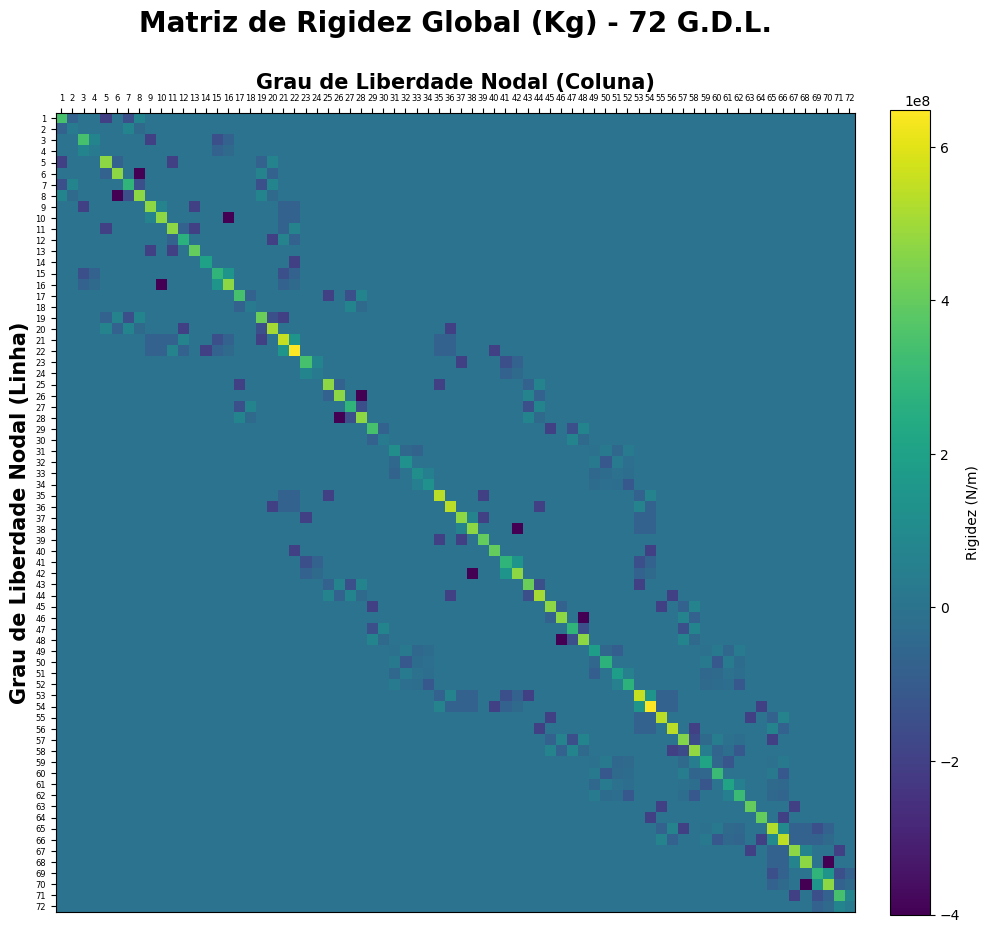

Semi-largura de banda da matriz global (Kg): 21


In [8]:
maxgdl = 2 * len(nos) # Número de graus de liberdade totais do sistema 2D
Kg = np.zeros([maxgdl, maxgdl])

print(f'Dimensões da matriz de rigidez global (Kg): {Kg.shape}') 
print(f'Total de elementos em Kg: {Kg.size}') 

for linha in barras.itertuples(): 
    NI, NF = linha.NI, linha.NF
    A, E, L = linha.A, linha.E, linha.L
    SEN, COS = linha.SEN, linha.COS
    
    # Matriz de rigidez no sistema local para treliça plana
    Kl = (E * A / L) * np.array([[ 1,  0, -1,  0],
                                 [ 0,  0,  0,  0], 
                                 [-1,  0,  1,  0],
                                 [ 0,  0,  0,  0]])

    # Matriz de rotação
    Mrot = np.array([[ COS,  SEN,    0,    0],
                     [-SEN,  COS,    0,    0],
                     [   0,    0,  COS,  SEN],
                     [   0,    0, -SEN,  COS]])
    
    # Matriz de rigidez global a nível nodal (@ é multiplicação matricial)
    Kgnodal = Mrot.T @ Kl @ Mrot 
    
    # Mapeamento dos graus de liberdade e alocação topológica (Otimizado via np.ix_)
    idx = [2*NI - 2, 2*NI - 1, 2*NF - 2, 2*NF - 1]
    Kg[np.ix_(idx, idx)] += Kgnodal
    
# Visualização da Matriz de Rigidez
plt.figure(figsize=(10, 10))
im = plt.imshow(Kg, cmap='viridis', interpolation='nearest', aspect='equal')
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Rigidez (N/m)')

plt.xlabel('Grau de Liberdade Nodal (Coluna)', fontsize=15, weight='bold')
plt.ylabel('Grau de Liberdade Nodal (Linha)', fontsize=15, weight='bold')
plt.title(f'Matriz de Rigidez Global (Kg) - {maxgdl} G.D.L.\n', fontsize=20, weight='bold')

plt.xticks(ticks=np.arange(maxgdl), labels=np.arange(1, maxgdl + 1), fontsize=6)
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.yticks(ticks=np.arange(maxgdl), labels=np.arange(1, maxgdl + 1), fontsize=6)

plt.tight_layout()
plt.show()

# Verificação da semi-largura de banda da matriz gerada
linhas_nz, colunas_nz = np.where(Kg != 0)
semi_banda = np.max(np.abs(linhas_nz - colunas_nz))
print(f"Semi-largura de banda da matriz global (Kg): {semi_banda}")

### APLICAÇÃO DAS CONDIÇÕES DE CONTORNO (APOIOS)

Até o momento, a Matriz de Rigidez Global ($K_g$) descreve uma estrutura "solta no espaço", sendo uma matriz singular. Para tornarmos o sistema solucionável, nós ancoramos o modelo introduzindo os apoios.

Para evitarmos o particionamento pesado da matriz e um remapeamento complexo que prejudicaria a análise dinâmica posterior, nós empregamos a **Técnica de Substituição Algébrica**. Operando sobre uma cópia da matriz ($K_{gc}$), executamos os seguintes passos:

*   **Rastreio e Isolamento:** Varremos os nós buscando bloqueios de translação ($R_x = 1$ ou $R_y = 1$). Ao encontrarmos, sobrescrevemos a linha e a coluna inteiras associadas ao GDL com zeros.
*   **Imposição da Identidade:** A interseção (diagonal principal) recebe o valor unitário ($1$). Ao emparelharmos isso com o vetor de forças (onde alocaremos zero para este GDL), impomos a equação trivial $1 \cdot \Delta = 0$, garantindo deslocamento nulo no apoio.

Ao re-plotarmos a Matriz Condicionada ($K_{gc}$), os GDLs restritos ficam evidentes como pontos isolados na diagonal, mostrando que impusemos estabilidade sem corromper a meia-largura de banda.

Nó 16: Deslocamento restringido em X.
Nó 16: Deslocamento restringido em Y.
Nó 17: Deslocamento restringido em Y.


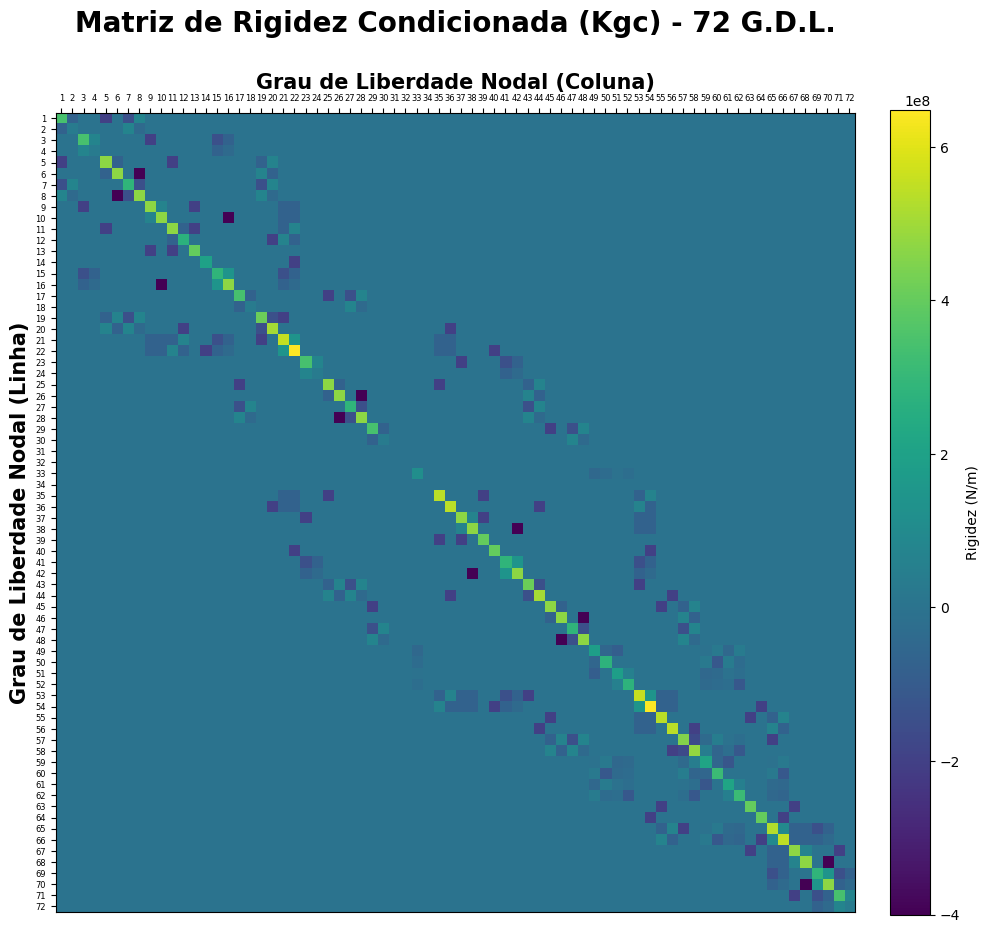

Semi-largura de banda da matriz condicionada (Kgc): 19


In [9]:
# Cópia da matriz de rigidez para aplicação dos apoios
Kgc = np.copy(Kg)

for row in nos.itertuples(): 
    idx_x = 2 * row.Index - 2
    idx_y = 2 * row.Index - 1
    
    # Penalização matricial: zera linha/coluna e define 1 na diagonal principal
    if row.RX == 1:
        Kgc[:, idx_x] = 0
        Kgc[idx_x, :] = 0
        Kgc[idx_x, idx_x] = 1
        print(f'Nó {row.Index}: Deslocamento restringido em X.')
        
    if row.RY == 1:
        Kgc[:, idx_y] = 0
        Kgc[idx_y, :] = 0
        Kgc[idx_y, idx_y] = 1
        print(f'Nó {row.Index}: Deslocamento restringido em Y.')

plt.figure(figsize=(10, 10))
im = plt.imshow(Kgc, cmap='viridis', interpolation='nearest', aspect='equal')
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Rigidez (N/m)')

plt.xlabel('Grau de Liberdade Nodal (Coluna)', fontsize=15, weight='bold')
plt.ylabel('Grau de Liberdade Nodal (Linha)', fontsize=15, weight='bold')
plt.title(f'Matriz de Rigidez Condicionada (Kgc) - {maxgdl} G.D.L.\n', fontsize=20, weight='bold')

plt.xticks(ticks=np.arange(maxgdl), labels=np.arange(1, maxgdl + 1), fontsize=6)
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.yticks(ticks=np.arange(maxgdl), labels=np.arange(1, maxgdl + 1), fontsize=6)

plt.tight_layout()
plt.show()

linhas_nz, colunas_nz = np.where(Kgc != 0)
semi_banda = np.max(np.abs(linhas_nz - colunas_nz))
print(f"Semi-largura de banda da matriz condicionada (Kgc): {semi_banda}")

### VERIFICAÇÃO DE INTEGRIDADE ESTÁTICA E CONDICIONAMENTO

Antes de chamarmos os solvers algébricos, nós realizamos uma auditoria espectral rigorosa para confirmarmos a sanidade topológica e a estabilidade cinemática do modelo. Nós extraímos os autovalores via `scipy.linalg.eigvalsh` e dividimos a validação em duas etapas:

**1. Consistência Topológica da Matriz Global ($K_g$)**
Pela mecânica clássica, um corpo flutuante 2D possui exatamente 3 movimentos de corpo rígido (duas translações e uma rotação). Exigimos que a matriz $K_g$ possua **exatamente 3 autovalores nulos**. Qualquer desvio aponta para nós soltos ou mecanismos instáveis internos.

**2. Estabilidade Cinemática da Matriz Condicionada ($K_{gc}$)**
Para que o sistema $F = K \cdot d$ tenha solução única, os apoios devem suprimir todos os movimentos de corpo rígido. A matriz condicionada $K_{gc}$ deve ser estritamente positiva definida, atestada pela **ausência total de autovalores nulos**. Se houver algum zero aqui, o modelo está hipostático.

In [10]:
print("Análise de Estabilidade e Condicionamento Matricial:\n")

# 1. Teste da Matriz Global Não Condicionada (Kg)
autovalores_Kg = np.linalg.eigvalsh(Kg)
modos_corpo_rigido = np.sum(autovalores_Kg < 1e-6) 

if modos_corpo_rigido == 3:
    print("✅ Kg OK: Matriz original perfeitamente montada (3 modos de corpo rígido esperados identificados).")
else:
    print(f"⚠️ ALERTA Kg: Encontrados {modos_corpo_rigido} modos singulares (Esperava-se 3).")
    print("   -> Maior que 3: Pode haver nós desconectados ou mecanismos.")
    print("   -> Menor que 3: Verifique falhas na topologia das barras.")

# 2. Teste da Matriz Condicionada (Kgc)
autovalores_Kgc = np.linalg.eigvalsh(Kgc)
modos_instaveis = np.sum(autovalores_Kgc < 1e-6)

if modos_instaveis == 0:
    print("✅ Kgc OK: Estrutura vinculada e estável. Sistema solucionável.")
else:
    print(f"🚨 ERRO Kgc: A estrutura condicionada ainda apresenta {modos_instaveis} graus de liberdade instáveis.")
    print("   -> A estrutura é hipostática. Verifique se os apoios fornecidos são suficientes.")

Análise de Estabilidade e Condicionamento Matricial:

✅ Kg OK: Matriz original perfeitamente montada (3 modos de corpo rígido esperados identificados).
✅ Kgc OK: Estrutura vinculada e estável. Sistema solucionável.


### MONTAGEM DO VETOR DE FORÇAS (COM PESO PRÓPRIO)

Para resolver o sistema de equilíbrio ($F = K_{gc} \cdot d$), nós construímos o vetor de cargas globais ($F$), concentrando as cargas externas nos nós e somando a ação do peso próprio.

Para garantirmos máxima performance, nós mesclamos o rateio nodal de peso físico com a vetorização por fatiamento matricial (*Slicing*) do NumPy:

* **Peso Próprio:** O peso físico da barra ($W = \rho \cdot A \cdot L \cdot g$) é calculado e rateado em 50% para os seus respectivos nós de extremidade.
* **Graus de Liberdade em X (Pares):** As forças horizontais externas (`FX`) são injetadas instantaneamente nas posições pares do vetor global.
* **Graus de Liberdade em Y (Ímpares):** Fatiamos as forças verticais externas (`FY`) e subtraímos o vetor de peso próprio nodal (já que a gravidade atua em -Y). Mapeamos este resultado nas posições ímpares.

In [11]:
# Aceleração da gravidade
g = 9.81
num_nos = len(nos)
peso_nodal = np.zeros(num_nos)

# Cálculo vetorizado do peso de cada barra (W = Densidade * Área * Comprimento * g)
peso_elemento = barras['RHO'].values * barras['A'].values * barras['L'].values * g

# Rateio do peso próprio concentrado (50% para cada nó adjacente da barra)
for ni, nf, p in zip(barras['NI'], barras['NF'], peso_elemento):
    peso_nodal[ni - 1] += p / 2.0
    peso_nodal[nf - 1] += p / 2.0

# Montagem do Vetor de Forças Global via Slicing
F = np.zeros(maxgdl)

# Graus de Liberdade em X (Índices pares): Apenas as cargas nodais horizontais
F[0::2] = nos['FX'].values

# Graus de Liberdade em Y (Índices ímpares): Cargas nodais verticais subtraídas do peso próprio estrutural
F[1::2] = nos['FY'].values - peso_nodal

print("Vetor de Forças Global (F) criado com as cargas externas e o peso próprio.")

Vetor de Forças Global (F) criado com as cargas externas e o peso próprio.


### RESOLUÇÃO DOS DESLOCAMENTOS NODAIS ESTÁTICOS

Com a estrutura vinculada e carregada, nós partimos para a resolução do sistema fundamental: $K_{gc} \cdot D_g = F_c$, dividindo o processo em três passos analíticos:

**1. Validação Numérica Final**
Para evitar falhas por *overflow*, nós checamos a singularidade através da função `np.linalg.slogdet`. Se o valor logarítmico indicar $-\infty$, bloqueamos a execução antes que ocorra um erro fatal de álgebra linear.

**2. Condicionamento do Vetor de Forças**
Para garantir matematicamente que o deslocamento no apoio seja nulo ($\Delta = 0$), nós forçamos zero na componente de força correspondente a ele no vetor $F_c$, mapeando isso de forma vetorizada com máscaras lógicas.

**3. Solução Algébrica**
Invocamos o solver direto nativo (`np.linalg.solve`), e fatiamos o vetor resposta global ($D_g$) de volta para o DataFrame de nós (`Dx` e `Dy`).

In [12]:
# Confirmação de regularidade da matriz de rigidez antes do solver estático
sinal, logdet = np.linalg.slogdet(Kgc)

if logdet == -np.inf:
    print("Alerta crítico: Matriz Singular encontrada na resolução (Determinante zero).")
else:
    print("Matriz aprovada. Executando solver linear...")

Matriz aprovada. Executando solver linear...


In [13]:
# Aplicação coerente de forças nulas nas restrições para garantir D = 0 nos apoios
Fc = np.copy(F)
mask_X = (nos['RX'] == 1).values
mask_Y = (nos['RY'] == 1).values

Fc[0::2][mask_X] = 0
Fc[1::2][mask_Y] = 0

# Solver nativo de álgebra linear resolvendo (Kgc * Dg = Fc)
Dg = np.linalg.solve(Kgc, Fc)

# Alocando vetor de deslocamentos global no dataframe de nós
nos['Dx'] = Dg[0::2]
nos['Dy'] = Dg[1::2] 

display(nos)

,X,Y,RX,RY,FX,FY,Dx,Dy
1,-5.25,30.0,0,0,0,-8000,-0.000364,-0.002669
2,9.75,30.0,0,0,0,-8000,0.000107,-0.002638
3,-2.25,30.0,0,0,0,0,-0.000277,-0.001833
4,-2.25,28.5,0,0,0,0,-0.000070,-0.001835
5,6.75,30.0,0,0,0,0,0.000020,-0.001818
6,0.75,30.0,0,0,0,0,-0.000178,-0.001603
7,3.75,30.0,0,0,0,0,-0.000079,-0.001600
8,6.75,28.5,0,0,0,0,-0.000180,-0.001820
9,-5.25,24.0,0,0,0,-8000,-0.000429,-0.002665
10,0.75,27.0,0,0,0,0,-0.000072,-0.001595


### PLOT DA ESTRUTURA DEFORMADA (CÁLCULO ESTÁTICO)

Como as deformações no regime elástico-linear ocorrem na ordem de milímetros (imperceptíveis a olho nu na escala métrica da estrutura), nós implementamos uma **Sobreposição com Amplificação Escalar**:

*   **Fator de Amplificação Visual:** Introduzimos o escalar `esc = 500` para exacerbar a deformação e evidenciar a tendência cinemática.
*   **Sobreposição de Estados:** Desenhamos a topologia original em linhas pontilhadas verdes (referencial estático) e sobrepomos a nova malha dilatada em linhas sólidas pretas.
*   **Conversão Quantitativa:** Convertamos e filtramos (via tolerância `> 0.001` mm) os deslocamentos em labels precisos, omitindo ruído numérico.
*   **Readequação Dinâmica:** O *bounding box* se recalcula dinamicamente para garantir que a estrutura dilatada permaneça perfeitamente enquadrada.

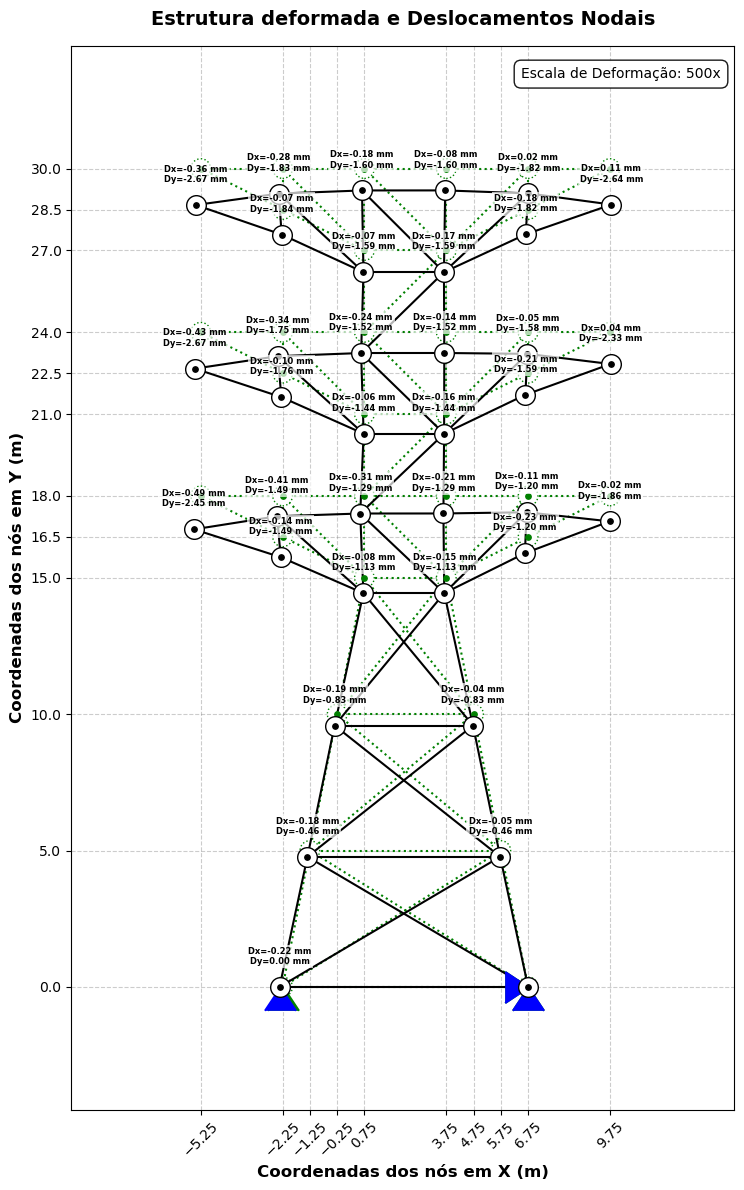

In [14]:
plt.figure(2, figsize=(15, 12))
plt.title('Estrutura deformada e Deslocamentos Nodais', fontsize=14, weight='bold', pad=15)

# Fator de escala visual da deformação (altere este valor para enfatizar os deslocamentos)
esc = 500

todas_coord_x = []
todas_coord_y = []

# Desenhando geometria deformada
for row in barras.itertuples(): 
    NI, NF = row.NI, row.NF
    
    xi, yi = nos.loc[NI, ['X', 'Y']]
    xf, yf = nos.loc[NF, ['X', 'Y']]
    
    # Posição indeformada original (verde pontilhado)
    plt.plot([xi, xf], [yi, yf], 'g:', zorder=2) 
    
    dxi, dyi = nos.loc[NI, ['Dx', 'Dy']]
    dxf, dyf = nos.loc[NF, ['Dx', 'Dy']]
    
    xid, yid = xi + (esc * dxi), yi + (esc * dyi)
    xfd, yfd = xf + (esc * dxf), yf + (esc * dyf)

    # Posição deformada ampliada (preto sólido)
    plt.plot([xid, xfd], [yid, yfd], 'k', zorder=4)  
        
# Detalhamento dos Nós e Valores
for row in nos.itertuples(): 
    X, Y, RX, RY, Dx, Dy = row.X, row.Y, row.RX, row.RY, row.Dx, row.Dy
    
    X_def = X + (esc * Dx)
    Y_def = Y + (esc * Dy)
    
    todas_coord_x.extend([X, X_def])
    todas_coord_y.extend([Y, Y_def])
 
    # Posições Iniciais
    plt.scatter(X, Y, s=200, c='white', edgecolors='green', linestyles=':', marker='o', zorder=3)
    plt.scatter(X, Y, s=15, c='green', marker='o', zorder=4)
    if RX == 1: plt.scatter(X, Y, s=500, color='green', marker=5, zorder=3) 
    if RY == 1: plt.scatter(X, Y, s=500, color='green', marker=6, zorder=3) 

    # Posições Deformadas
    plt.scatter(X_def, Y_def, s=200, c='white', edgecolors='black', marker='o', zorder=5)
    plt.scatter(X_def, Y_def, s=15, c='black', marker='o', zorder=6)
    if RX == 1: plt.scatter(X_def, Y_def, s=500, color='blue', marker=5, zorder=4) 
    if RY == 1: plt.scatter(X_def, Y_def, s=500, color='blue', marker=6, zorder=4) 
        
    # Anotações de deslocamentos relevantes (convertido para mm)
    dx_mm, dy_mm = Dx * 1000, Dy * 1000
    if abs(dx_mm) > 0.001 or abs(dy_mm) > 0.001:
        plt.annotate(f'Dx={dx_mm:.2f} mm\nDy={dy_mm:.2f} mm', 
                     xy=(X_def, Y_def), xytext=(0, 15),
                     textcoords='offset points', fontsize=6, ha='center', va='bottom', 
                     zorder=10, weight='bold',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5))

plt.xlabel('Coordenadas dos nós em X (m)', fontsize=12, weight='bold')
plt.ylabel('Coordenadas dos nós em Y (m)', fontsize=12, weight='bold')
plt.xticks(sorted(nos['X'].unique()), rotation=45)
plt.yticks(sorted(nos['Y'].unique()))
plt.grid(visible=True, which='major', color='gray', linestyle='--', alpha=0.4, zorder=-2)

plt.text(0.980, 0.980, f'Escala de Deformação: {esc}x', 
         transform=plt.gca().transAxes, fontsize=10, ha='right', va='top', 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))

dim_ref = max(max(todas_coord_x) - min(todas_coord_x), max(todas_coord_y) - min(todas_coord_y))
margem = dim_ref * 0.15
plt.xlim(min(todas_coord_x) - margem, max(todas_coord_x) + margem)
plt.ylim(min(todas_coord_y) - margem, max(todas_coord_y) + margem)

plt.gca().set_aspect('equal')
plt.tight_layout() 
plt.show()

### CÁLCULO E VISUALIZAÇÃO DAS REAÇÕES DE APOIO

Para extrairmos as reações vinculares, nós resgatamos a Matriz de Rigidez Global original ($K_g$) e o vetor de forças externas original ($F$). O cálculo é obtido através da operação vetorial $R = (K_g \cdot D_g) - F$.

Para a renderização do **Diagrama de Corpo Livre**, nós adotamos as seguintes diretrizes:

*   **Diferenciação Funcional (Cores):** Nós plotamos as ações externas (aplicadas) em vermelho, e as reações reativas em verde.
*   **Vetorização Direcional Dinâmica:** O código orienta a geometria das setas algebricamente, lendo o sinal vetorial do esforço processado e invertendo quando necessário.
*   **Conversão e Escalonamento:** Os valores em Newtons são exibidos diretamente em kN e escalonados junto com o *offset* da estrutura, mantendo o diagrama esteticamente coeso.

In [15]:
# Reação em apoios = Força Interna Recuperadora (Kg * Dg) menos a Força Externa aplicada (F)
R = Kg @ Dg - F
print("Vetor resultante das Reações de Apoio (R):")
print(np.round(R, 3))

Vetor resultante das Reações de Apoio (R):
[   -0.       -0.       -0.       -0.        0.        0.        0.
    -0.        0.        0.       -0.        0.       -0.       -0.
     0.        0.        0.        0.        0.        0.       -0.
    -0.        0.       -0.       -0.        0.        0.       -0.
    -0.        0.       -0.    56205.775     0.    56205.775     0.
    -0.       -0.        0.       -0.        0.       -0.        0.
     0.        0.        0.        0.        0.       -0.        0.
     0.       -0.       -0.        0.       -0.       -0.       -0.
     0.       -0.        0.       -0.       -0.        0.       -0.
    -0.       -0.       -0.       -0.       -0.        0.       -0.
    -0.        0.   ]


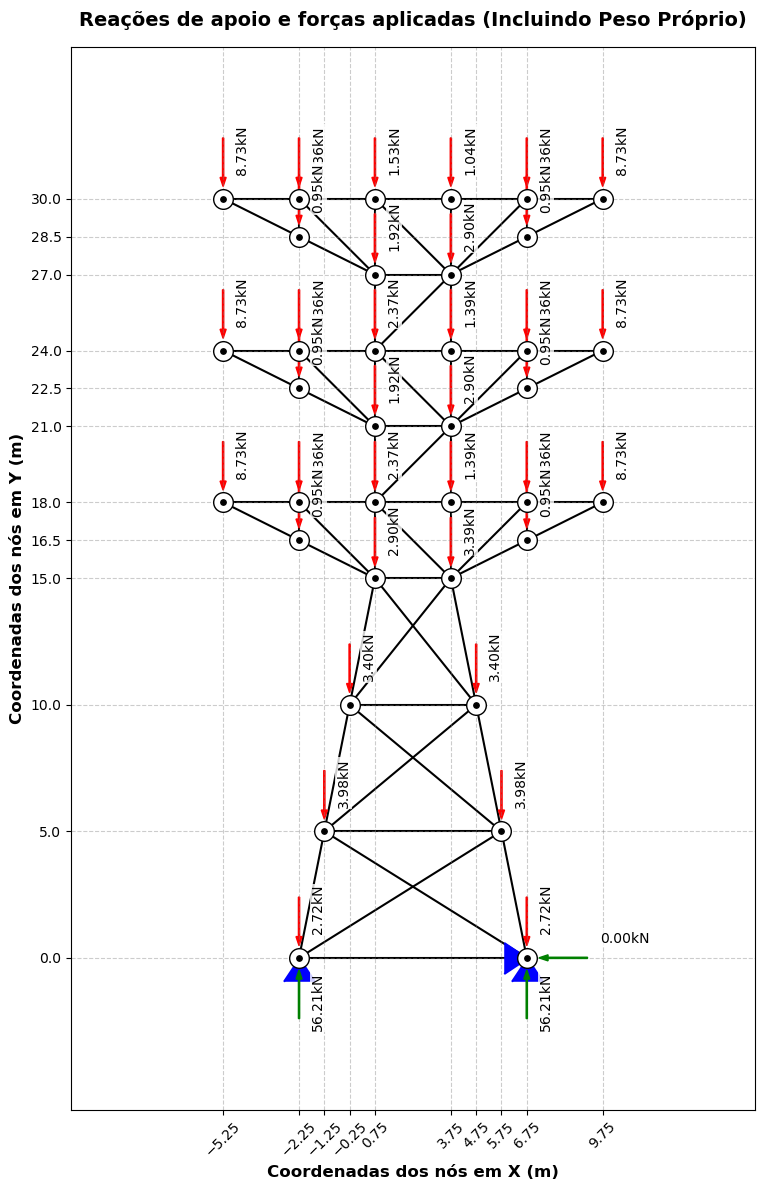

In [16]:
plt.figure(1, figsize=(15, 12))
plt.title('Reações de apoio e forças aplicadas (Incluindo Peso Próprio)', fontsize=14, weight='bold', pad=15)

dim_ref = max(nos['X'].max() - nos['X'].min(), nos['Y'].max() - nos['Y'].min())
if dim_ref == 0: dim_ref = 1.0
off = dim_ref * 0.08

for row in barras.itertuples(): 
    xi, yi = nos.loc[row.NI, ['X', 'Y']]
    xf, yf = nos.loc[row.NF, ['X', 'Y']]
    plt.plot([xi, xf], [yi, yf], color='black', zorder=1)
    
for row in nos.itertuples():
    X, Y, RX, RY = row.X, row.Y, row.RX, row.RY
    idx = row.Index
 
    plt.scatter(X, Y, s=200, c='white', edgecolors='black', marker='o', zorder=3)
    plt.scatter(X, Y, s=15, c='black', marker='o', zorder=4)

    idx_x = 2 * idx - 2
    idx_y = 2 * idx - 1
    
    # Extração direta do vetor global consolidado F (Planilha + Peso Próprio)
    FX_total = F[idx_x]
    FY_total = F[idx_y]
        
    # Plotagem das Reações de Apoio (Verde)
    if RX == 1:
        plt.scatter(X, Y, s=500, color='blue', marker=5, zorder=2)
        ReacX = R[idx_x]
        dx = off if ReacX >= 0 else -off
        inicio_x = X - dx
        plt.arrow(inicio_x, Y, dx*0.8, 0, color='green', width=off*0.02, head_width=off*0.1, length_includes_head=True, zorder=3)
        plt.text(inicio_x - dx*0.2, Y + off*0.2, f'{abs(ReacX)/1000:.2f}kN', va='bottom',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))
        
    if RY == 1:
        plt.scatter(X, Y, s=500, color='blue', marker=6, zorder=2)
        ReacY = R[idx_y]
        dy = off if ReacY >= 0 else -off
        inicio_y = Y - dy
        plt.arrow(X, inicio_y, 0, dy*0.8, color='green', width=off*0.02, head_width=off*0.1, length_includes_head=True, zorder=3)
        plt.text(X + off*0.2, inicio_y - dy*0.2, f'{abs(ReacY)/1000:.2f}kN', va='bottom', rotation=90,
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

    # Plotagem das Forças Ativas Totais (Vermelho) com filtro de tolerância numérica
    if abs(FX_total) > 1e-4:
        dx = off if FX_total > 0 else -off
        inicio_x = X - dx
        plt.arrow(inicio_x, Y, dx*0.8, 0, color='red', width=off*0.02, head_width=off*0.1, length_includes_head=True)
        plt.text(inicio_x - dx*0.5, Y + off*0.2, f'{abs(FX_total)/1000:.2f}kN', va='top',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))
                 
    if abs(FY_total) > 1e-4:
        dy = off if FY_total > 0 else -off
        inicio_y = Y - dy
        plt.arrow(X, inicio_y, 0, dy*0.8, color='red', width=off*0.02, head_width=off*0.1, length_includes_head=True)
        plt.text(X + off*0.2, inicio_y - dy*0.2, f'{abs(FY_total)/1000:.2f}kN', va='top', rotation=90,
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))
        
coordenadas_x = nos['X'].unique()
coordenadas_y = nos['Y'].unique()

plt.xlabel('Coordenadas dos nós em X (m)', fontsize=12, weight='bold')
plt.ylabel('Coordenadas dos nós em Y (m)', fontsize=12, weight='bold')
plt.xticks(coordenadas_x, rotation=45)
plt.yticks(coordenadas_y)
plt.grid(visible=True, which='major', color='gray', linestyle='--', alpha=0.4, zorder=-2)

margem = dim_ref * 0.20
plt.xlim(coordenadas_x.min() - margem, coordenadas_x.max() + margem)
plt.ylim(coordenadas_y.min() - margem, coordenadas_y.max() + margem)
plt.gca().set_aspect('equal')
plt.tight_layout() 
plt.show()

### ESFORÇOS INTERNOS AXIAIS NAS BARRAS

Com os deslocamentos globais calculados, nós avançamos para a determinação da resposta mecânica de cada elemento. Em treliças, recuperamos exclusivamente esforços normais (axiais) de tração ou compressão, sem momentos flectores ou cortantes.

Nós recuperamos os esforços internos percorrendo as seguintes etapas:

1. **Isolamento Cinemático do Elemento:** Para cada barra, mapeamos e extraímos a sua fração cinemática específica ($D_{lg}$) do vetor global de deslocamentos.
2. **Transformação de Coordenadas:** Nós projetamos os deslocamentos para o sistema local da barra via Matriz de Rotação ($D_l = M_{rot} \cdot D_{lg}$).
3. **Cálculo das Forças Internas:** Multiplicando pela Rigidez Local ($K_l$), o terceiro termo deste vetor correspondente indica mecanicamente o esforço axial final da barra.

**Representação Gráfica e Diagramação Estrutural:**
Para auditar o projeto com agilidade, nós criamos um código de cores semântico:
*   **Vermelho:** Tração (valores positivos).
*   **Azul:** Compressão (valores negativos).
*   **Preto:** Esforço Nulo.

Adicionalmente, calculamos o ângulo através do arco-tangente para posicionar o texto de esforço rigorosamente alinhado com o eixo espacial do seu respectivo elemento.

In [17]:
ESF = []

for row in barras.itertuples(): 
    NI, NF = row.NI, row.NF
    A, E, L = row.A, row.E, row.L
    SEN, COS = row.SEN, row.COS
    
    Kl = (E * A / L) * np.array([[ 1,  0, -1,  0],
                                 [ 0,  0,  0,  0], 
                                 [-1,  0,  1,  0],
                                 [ 0,  0,  0,  0]])

    Mrot = np.array([[ COS,  SEN,    0,    0],
                     [-SEN,  COS,    0,    0],
                     [   0,    0,  COS,  SEN],
                     [   0,    0, -SEN,  COS]])
    
    idx = [2*NI - 2, 2*NI - 1, 2*NF - 2, 2*NF - 1]
    
    # Extração dos deslocamentos referentes a esta barra
    Dlg = Dg[idx] 
    Dl = Mrot @ Dlg  
    
    # O esforço axial (tração/compressão) é o terceiro elemento no sistema local da barra
    Fl = Kl @ Dl
    FAx = Fl[2] 
    ESF.append(FAx)

barras['ESF'] = ESF
display(barras)

,NI,NF,A,E,RHO,L,SEN,COS,ESF
1,17,16,0.003,200000000000,7850,9.000000,0.000000,1.000000,1.495494e+04
2,17,26,0.003,200000000000,7850,5.099020,0.980581,0.196116,-5.144540e+04
3,17,25,0.003,200000000000,7850,9.433981,0.529999,0.847998,-5.737829e+03
4,16,26,0.003,200000000000,7850,9.433981,0.529999,-0.847998,-5.737829e+03
5,16,25,0.003,200000000000,7850,5.099020,0.980581,-0.196116,-5.144540e+04
6,26,25,0.003,200000000000,7850,7.000000,0.000000,1.000000,1.129629e+04
7,26,31,0.003,200000000000,7850,5.099020,0.980581,0.196116,-4.374018e+04
8,26,30,0.003,200000000000,7850,7.810250,0.640184,0.768221,-1.033782e+04
9,25,31,0.003,200000000000,7850,7.810250,0.640184,-0.768221,-1.033782e+04
10,25,30,0.003,200000000000,7850,5.099020,0.980581,-0.196116,-4.374018e+04


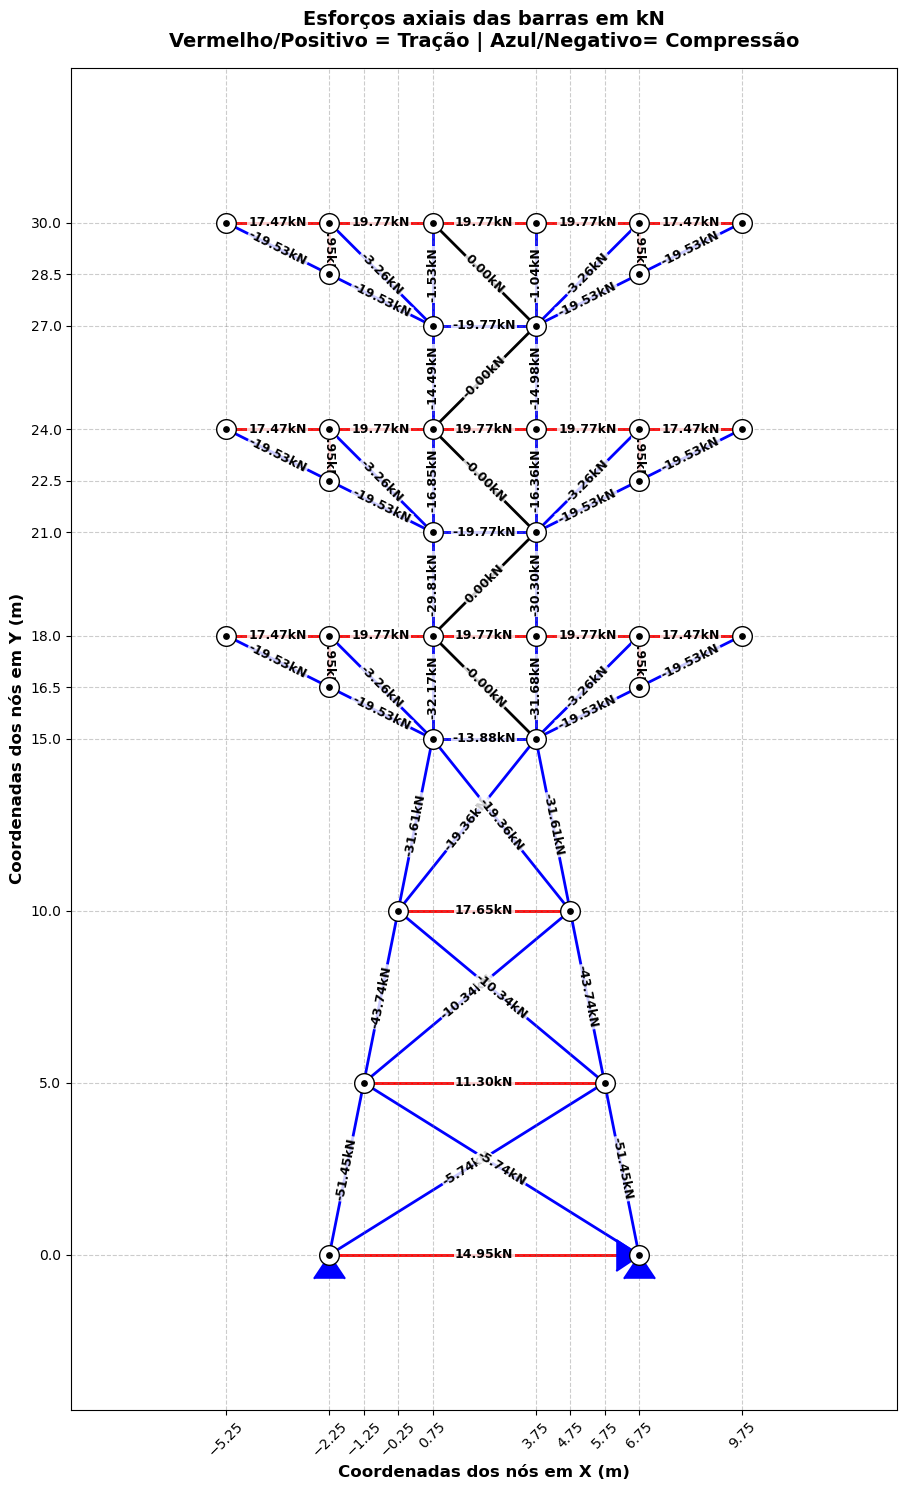

In [18]:
plt.figure(5, figsize=(15,15))
plt.title('Esforços axiais das barras em kN\nVermelho/Positivo = Tração | Azul/Negativo= Compressão', fontsize=14, weight='bold', pad=15)

for row in barras.itertuples(): 
    NI, NF, ESF_val = row.NI, row.NF, row.ESF
    xi, yi = nos.loc[NI, ['X', 'Y']]
    xf, yf = nos.loc[NF, ['X', 'Y']]
    
    dy, dx = yf - yi, xf - xi
    ANG = np.degrees(np.arctan2(dy, dx))
    if ANG > 90:
        ANG -= 180
    elif ANG < -90:
        ANG += 180
    
    # Tolerância estrita para barrar numéricos nulos reais de flutuações
    if abs(ESF_val) < 1e-4:
        cor = 'k'
    elif ESF_val > 0:
        cor = 'r' # Tração
    else: 
        cor = 'b' # Compressão
        
    plt.plot([xi, xf], [yi, yf], cor, zorder=-1, linewidth=2)

    plt.text(np.mean([xi, xf]), np.mean([yi, yf]),
             f'{ESF_val/1000:.2f}kN',
             rotation=ANG,
             horizontalalignment='center',
             verticalalignment='center',
             size=9,
             weight='bold',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))
 
for row in nos.itertuples(): 
    X, Y, RX, RY = row.X, row.Y, row.RX, row.RY
    plt.scatter(X, Y, s=200, c='white', edgecolors='black', marker='o', zorder=3)
    plt.scatter(X, Y, s=15, c='black', marker='o', zorder=4)
    
    if RX == 1: plt.scatter(X, Y, s=500, color='blue', marker=5, zorder=2) 
    if RY == 1: plt.scatter(X, Y, s=500, color='blue', marker=6, zorder=2) 

coordenadas_x = nos['X'].unique()
coordenadas_y = nos['Y'].unique()

plt.xlabel('Coordenadas dos nós em X (m)', fontsize=12, weight='bold')
plt.ylabel('Coordenadas dos nós em Y (m)', fontsize=12, weight='bold')
plt.xticks(coordenadas_x, rotation=45)
plt.yticks(coordenadas_y)
plt.grid(visible=True, which='major', color='gray', linestyle='--', alpha=0.4, zorder=-2)

dim_ref = max(nos['X'].max() - nos['X'].min(), nos['Y'].max() - nos['Y'].min())
if dim_ref == 0: dim_ref = 1.0
margem = dim_ref * 0.15
plt.xlim(coordenadas_x.min() - margem, coordenadas_x.max() + margem)
plt.ylim(coordenadas_y.min() - margem, coordenadas_y.max() + margem)
plt.gca().set_aspect('equal')
plt.tight_layout() 
plt.show()

### MONTAGEM DA MATRIZ DE MASSA CONCENTRADA (LUMPED)

Para avançarmos para a dinâmica, nós adotamos o modelo de massas concentradas, gerando uma matriz global diagonal. A massa que associamos a cada nó é obtida da soma de duas parcelas:

1. **Massa Estrutural:** Calculamos a massa física de cada elemento ($m = \rho \cdot A \cdot L$) e a distribuímos em 50% entre os nós de extremidade.
2. **Cargas Permanentes Adicionais:** Nós convertemos as forças nodais verticais em massa, dividindo-as pela aceleração da gravidade ($m = \frac{\vert{}F_y\vert{}}{g}$).

Alocamos o cômputo final a ambos os graus de liberdade translacionais de cada nó (X e Y) e exibimos a matriz $[M]$ em um *heatmap*.

Matriz de Massa Global Concentrada (Lumped) gerada com sucesso!
Dimensão da Matriz M_global: (72, 72)



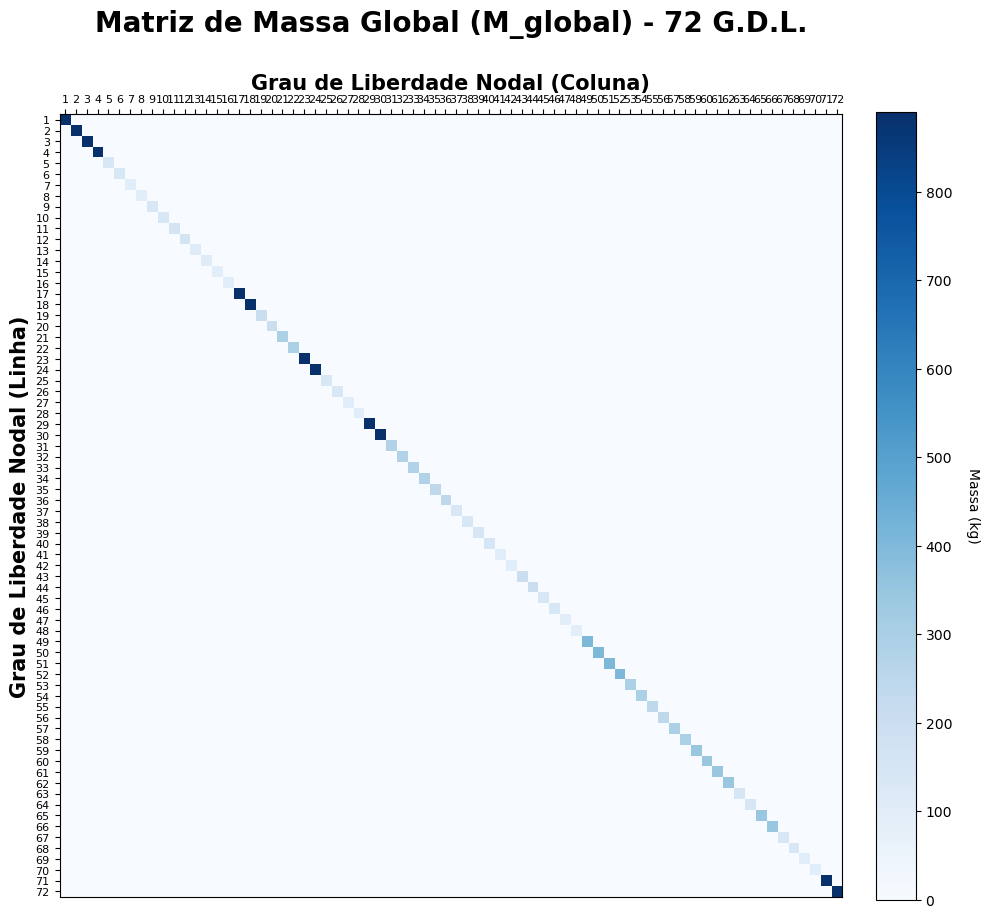

In [19]:
g = 9.81 
num_nos = len(nos)
massa_nodal = np.zeros(num_nos)

# 1. Parcela Estrutural (Vetorizada)
massa_elemento = barras['RHO'].values * barras['A'].values * barras['L'].values

for ni, nf, m in zip(barras['NI'], barras['NF'], massa_elemento):
    massa_nodal[ni - 1] += m / 2.0
    massa_nodal[nf - 1] += m / 2.0

# 2. Parcela Permanentes Adicionais (Forças convertidas)
massa_nodal += np.abs(nos['FY'].values) / g

# Expansão Diagonal para 2 Graus de Liberdade
M_diag = np.zeros(num_nos * 2)
M_diag[0::2] = massa_nodal  # Translacional X
M_diag[1::2] = massa_nodal  # Translacional Y
M_global = np.diag(M_diag)

print("Matriz de Massa Global Concentrada (Lumped) gerada com sucesso!")
print(f"Dimensão da Matriz M_global: {M_global.shape}\n")

plt.figure(figsize=(10, 10))
im = plt.imshow(M_global, cmap='Blues', interpolation='nearest', aspect='equal')
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Massa (kg)', rotation=270, labelpad=20)

n_gdl = M_global.shape[0]
plt.title(f'Matriz de Massa Global (M_global) - {n_gdl} G.D.L.\n', fontsize=20, weight='bold')
plt.xlabel('Grau de Liberdade Nodal (Coluna)', fontsize=15, weight='bold')
plt.ylabel('Grau de Liberdade Nodal (Linha)', fontsize=15, weight='bold')
plt.xticks(ticks=np.arange(n_gdl), labels=np.arange(1, n_gdl + 1), fontsize=8)

ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.yticks(ticks=np.arange(n_gdl), labels=np.arange(1, n_gdl + 1), fontsize=8)
plt.tight_layout()
plt.show()

### ANÁLISE DINÂMICA (AUTOVALORES): FREQUÊNCIAS NATURAIS DA ESTRUTURA

Nós formulamos agora o problema clássico de autovalores e autovetores (vibração livre não amortecida), procedendo em três etapas:

**1. Imposição das Condições de Contorno e Particionamento**
Particionamos as matrizes separando GDLs livres e restritos para evitarmos singularidades, isolando $[K_{livre}]$ e $[M_{livre}]$.

**2. Solução do Problema Generalizado de Autovalores**
Nós extraímos as raízes da equação $[K_{livre}] \cdot \{\Phi\} = \lambda \cdot [M_{livre}] \cdot \{\Phi\}$ para encontrarmos os autovalores (frequências) e autovetores (formas modais). Filtramos os resultados e os convertemos para Hertz (Hz).

**3. Representação Gráfica do Espectro de Frequências**
Nós disponibilizamos dois diagramas visuais simultâneos:

*   **Espectro Linear:** Deixa em evidência o **Modo Fundamental**, que governa grande parte da nossa resposta estrutural.
*   **Espectro Logarítmico:** Focamos nesta escala para garantir a legibilidade dos modos superiores, que disparam assintoticamente nas altas frequências.

Tratamento de Matrizes Livres:
Total de G.D.L. originais: 72
G.D.L. restritos removidos: 3
Dimensão das matrizes para análise modal: (69, 69)

Análise concluída: Encontrados 69 modos de vibração flexíveis.
Primeiras 10 Frequências Naturais da estrutura:
Modo 1: 1.92 Hz
Modo 2: 6.23 Hz
Modo 3: 9.03 Hz
Modo 4: 10.61 Hz
Modo 5: 11.06 Hz
Modo 6: 14.68 Hz
Modo 7: 15.00 Hz
Modo 8: 18.55 Hz
Modo 9: 28.27 Hz
Modo 10: 29.64 Hz


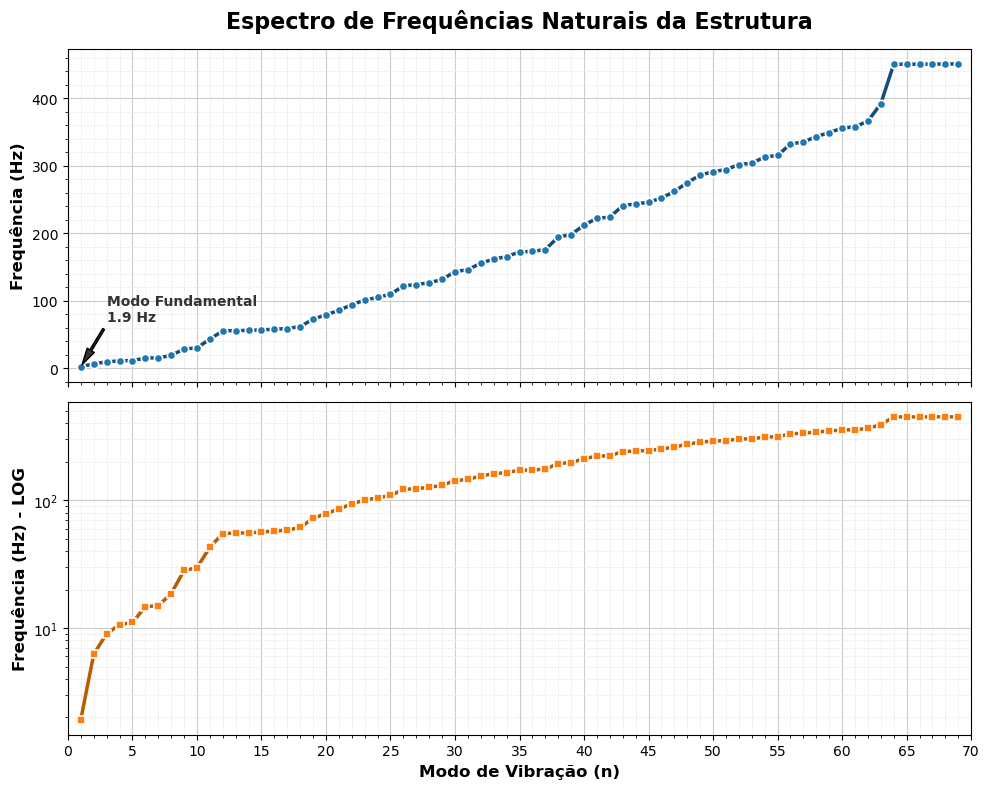

In [20]:
# Aplicação explícita dos apoios na matriz (separando G.D.L Livres e Restritos)
gdl_restritos = []
for i, row in enumerate(nos.itertuples()):
    if row.RX == 1.0: gdl_restritos.append(2 * i)
    if row.RY == 1.0: gdl_restritos.append(2 * i + 1)

gdl_totais = np.arange(maxgdl)
gdl_livres = np.setdiff1d(gdl_totais, gdl_restritos)

Kg_livre = Kg[np.ix_(gdl_livres, gdl_livres)]
M_livre = M_global[np.ix_(gdl_livres, gdl_livres)]

print("Tratamento de Matrizes Livres:")
print(f"Total de G.D.L. originais: {maxgdl}")
print(f"G.D.L. restritos removidos: {len(gdl_restritos)}")
print(f"Dimensão das matrizes para análise modal: {Kg_livre.shape}\n")

# Eigensolver otimizado para matrizes simétricas (Kg_livre * V = lambda * M_livre * V)
autovalores, autovetores = eigh(Kg_livre, M_livre)

tol = 1e-6
idx_validos = autovalores > tol
autovalores_validos = autovalores[idx_validos]
modos_de_vibracao = autovetores[:, idx_validos]

# Extração das Frequências Modais
omega = np.sqrt(autovalores_validos) # (rad/s)
f_natural = omega / (2 * np.pi)      # (Hz)

print(f"Análise concluída: Encontrados {len(f_natural)} modos de vibração flexíveis.")
print("Primeiras 10 Frequências Naturais da estrutura:")
for i, f in enumerate(f_natural[:10]):
    print(f"Modo {i+1}: {f:.2f} Hz")

# Gráficos Espectrais de Frequência (Linear e Logarítmico)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
modos_idx = np.arange(1, len(f_natural) + 1)

ax1.plot(modos_idx, f_natural, marker='o', markersize=6, markerfacecolor='#1f77b4', 
         markeredgecolor='white', markeredgewidth=1.2, linestyle='-', color='#154c79', linewidth=2.5)
ax1.set_title('Espectro de Frequências Naturais da Estrutura', fontsize=16, weight='bold', pad=15)
ax1.set_ylabel('Frequência (Hz)', fontsize=12, weight='bold')
ax1.grid(True, which='major', color='#cccccc', linestyle='-', linewidth=0.8)
ax1.grid(True, which='minor', color='#e6e6e6', linestyle='--', linewidth=0.5)
ax1.minorticks_on()

if len(f_natural) > 0:
    ax1.annotate(f'Modo Fundamental\n{f_natural[0]:.1f} Hz', 
                 xy=(1, f_natural[0]), xytext=(3, f_natural[0] + (np.max(f_natural)*0.15)),
                 arrowprops=dict(facecolor='#333333', shrink=0.05, width=1.5, headwidth=6),
                 fontsize=10, weight='bold', color='#333333')

ax2.plot(modos_idx, f_natural, marker='s', markersize=6, markerfacecolor='#ff7f0e', 
         markeredgecolor='white', markeredgewidth=1.2, linestyle='-', color='#b85c00', linewidth=2.5)
ax2.set_yscale('log')
ax2.set_xlabel('Modo de Vibração (n)', fontsize=12, weight='bold')
ax2.set_ylabel('Frequência (Hz) - LOG', fontsize=12, weight='bold')
ax2.grid(True, which='major', color='#cccccc', linestyle='-', linewidth=0.8)
ax2.grid(True, which='minor', color='#e6e6e6', linestyle='--', linewidth=0.5)
ax2.set_xlim(0, len(f_natural) + 1)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=15))

plt.subplots_adjust(hspace=0.08)
plt.tight_layout()
plt.show()

### REPRESENTAÇÃO GRÁFICA DOS MODOS DE VIBRAÇÃO (FORMAS MODAIS)

Para visualizarmos o comportamento dinâmico e o fenômeno de ressonância natural, nós renderizamos espacialmente as formas modais, limitando aos primeiros dez modos principais:

**1. Recomposição do Vetor de Deslocamentos**
Nós expandimos o autovetor de volta ao sistema global. Repomos os GDLs dos apoios com deslocamento estritamente nulo, garantindo um referencial fixo.

**2. Amplificação Cinemática**
Como autovetores indicam apenas proporções relativas e não unidades absolutas, nós implementamos um fator escalar dinâmico. Exacerbamos visualmente as amplitudes de modo que o pico modal atinja proporções visíveis na interface do notebook (~15% da envoltória do projeto).

**3. Superposição Geométrica e Renderização**
Nós sobrepomos as duas configurações (estática em tracejado e vibracional em azul), cravando os eixos numa proporção ortogonal pura para não induzirmos nenhum falso *drift* no observador.

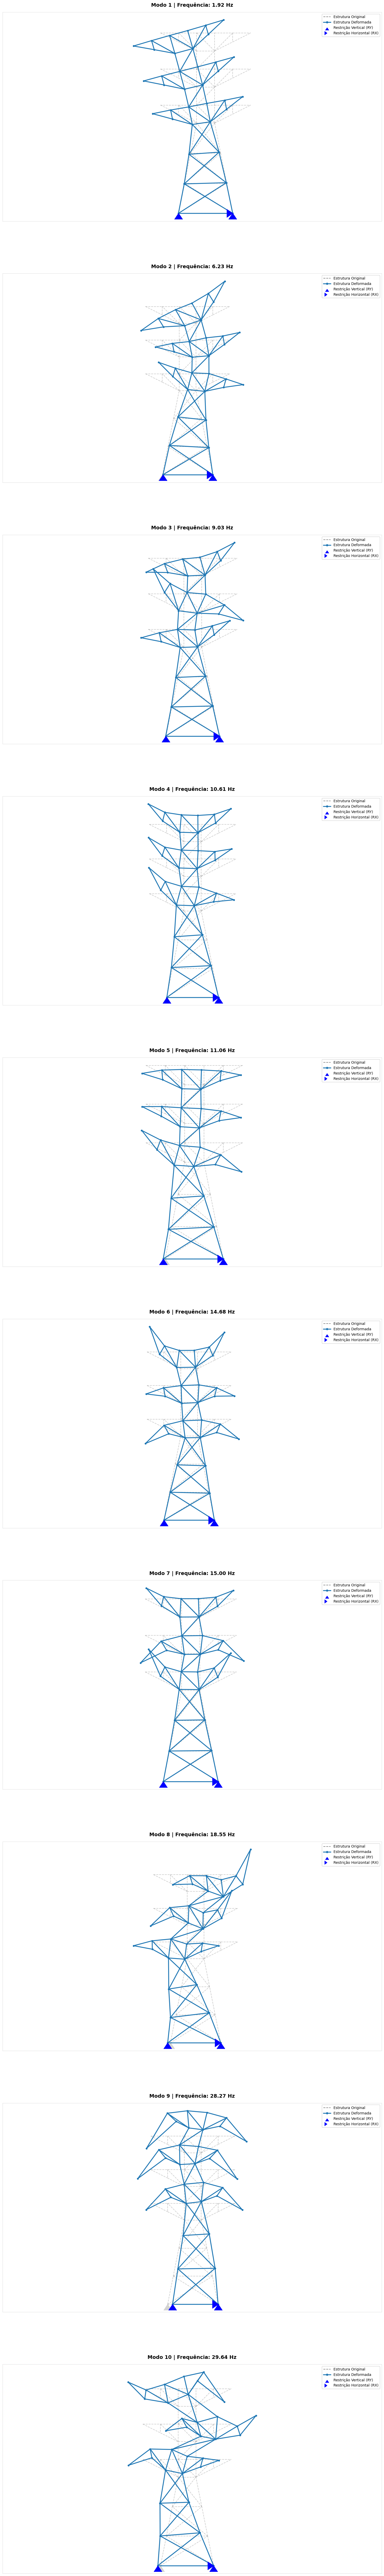

In [21]:
num_modos_plot = min(10, len(f_natural))
fig, axes = plt.subplots(num_modos_plot, 1, figsize=(15, 10 * num_modos_plot))
if num_modos_plot == 1: axes = [axes]

dim_x = nos['X'].max() - nos['X'].min()
dim_y = nos['Y'].max() - nos['Y'].min()
max_dim = max(dim_x, dim_y) if max(dim_x, dim_y) > 0 else 1.0 

for i in range(num_modos_plot):
    ax = axes[i]
    
    # Expansão do autovetor para incluir graus de liberdade zeros (apoios)
    phi_completo = np.zeros(maxgdl)
    phi_completo[gdl_livres] = modos_de_vibracao[:, i]
    
    max_desloc = np.max(np.abs(phi_completo))
    escala = (0.15 * max_dim) / max_desloc if max_desloc != 0 else 1.0
    
    for row in barras.itertuples():
        ni, nf = row.NI, row.NF
        xi, yi = nos.loc[ni, 'X'], nos.loc[ni, 'Y']
        xf, yf = nos.loc[nf, 'X'], nos.loc[nf, 'Y']
        
        idx_xi, idx_yi = 2*ni - 2, 2*ni - 1
        idx_xf, idx_yf = 2*nf - 2, 2*nf - 1
        
        xi_def = xi + escala * phi_completo[idx_xi]
        yi_def = yi + escala * phi_completo[idx_yi]
        xf_def = xf + escala * phi_completo[idx_xf]
        yf_def = yf + escala * phi_completo[idx_yf]
        
        ax.plot([xi, xf], [yi, yf], color='gray', linestyle='--', linewidth=1.5, alpha=0.4)
        ax.plot([xi_def, xf_def], [yi_def, yf_def], color='#1f77b4', linewidth=2.5, zorder=3)
        ax.plot([xi_def, xf_def], [yi_def, yf_def], marker='o', color='#1f77b4', markersize=4, zorder=4, linestyle='None')

    for idx, no in nos.iterrows():
        rx, ry, x, y = no['RX'], no['RY'], no['X'], no['Y']
        ni = int(idx)
        idx_x, idx_y = 2*ni - 2, 2*ni - 1
        
        x_def = x + escala * phi_completo[idx_x]
        y_def = y + escala * phi_completo[idx_y]
        
        if rx == 1.0: 
            ax.scatter(x, y, s=500, color='lightgray', marker=5, zorder=1)
            ax.scatter(x_def, y_def, s=500, color='blue', marker=5, zorder=5)
        if ry == 1.0: 
            ax.scatter(x, y, s=500, color='lightgray', marker=6, zorder=1)
            ax.scatter(x_def, y_def, s=500, color='blue', marker=6, zorder=5)

    legend_elements = [
        Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5, label='Estrutura Original'),
        Line2D([0], [0], color='#1f77b4', linestyle='-', linewidth=2.5, marker='o', markersize=5, label='Estrutura Deformada'),
        Line2D([0], [0], linestyle='None', marker=6, color='blue', markersize=10, label='Restrição Vertical (RY)'),
        Line2D([0], [0], linestyle='None', marker=5, color='blue', markersize=10, label='Restrição Horizontal (RX)')
    ]
    
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9, edgecolor='#cccccc')
    ax.set_title(f"Modo {i+1} | Frequência: {f_natural[i]:.2f} Hz", fontsize=14, weight='bold', pad=15)
    ax.axis('equal') 
    ax.grid(True, linestyle=':', color='#cccccc')
    ax.set_xticks([])
    ax.set_yticks([])
    
    for spine in ax.spines.values():
        spine.set_color('#dddddd')

plt.tight_layout()
plt.subplots_adjust(hspace=0.25)
plt.show()

## ANÁLISE SÍSMICA DA ESTRUTURA

### MODELAGEM DA EXCITAÇÃO SÍSMICA: FILTRO DE KANAI-TAJIMI E PSD

Para avaliarmos a resposta estrutural estocástica, nós empregamos o modelo empírico de Kanai-Tajimi para a Densidade Espectral de Potência (PSD). O procedimento foi implementado nas três fases abaixo:

**1. Formulação Analítica do Filtro Geotécnico**
Tratamos o solo como um oscilador que filtra e amplifica um ruído branco ideal que vem da rocha matriz. A equação analítica do domínio da frequência é definida por:

$$S(\omega) = S_0 \frac{\omega_g^4 + (2\xi_g\omega_g\omega)^2}{(\omega_g^2 - \omega^2)^2 + (2\xi_g\omega_g\omega)^2}$$

**2. Parametrização das Propriedades do Solo**
Nós parametrizamos as características geológicas do terreno. Para este solver, nós calibramos os valores empíricos para um **solo de rigidez média a firme** ($\omega_g = 15.0 \text{ rad/s}$ e $\xi_g = 0.60$), evitando picos extremos que não seriam condizentes com nosso cenário.

**3. Avaliação e Representação Espectral da Energia**
Varremos as frequências de interesse para gerarmos a curva PSD. O gráfico que nós apresentamos atesta visualmente onde se concentra o maior potencial de ressonância (a energia sísmica atuante contra as frequências da estrutura).

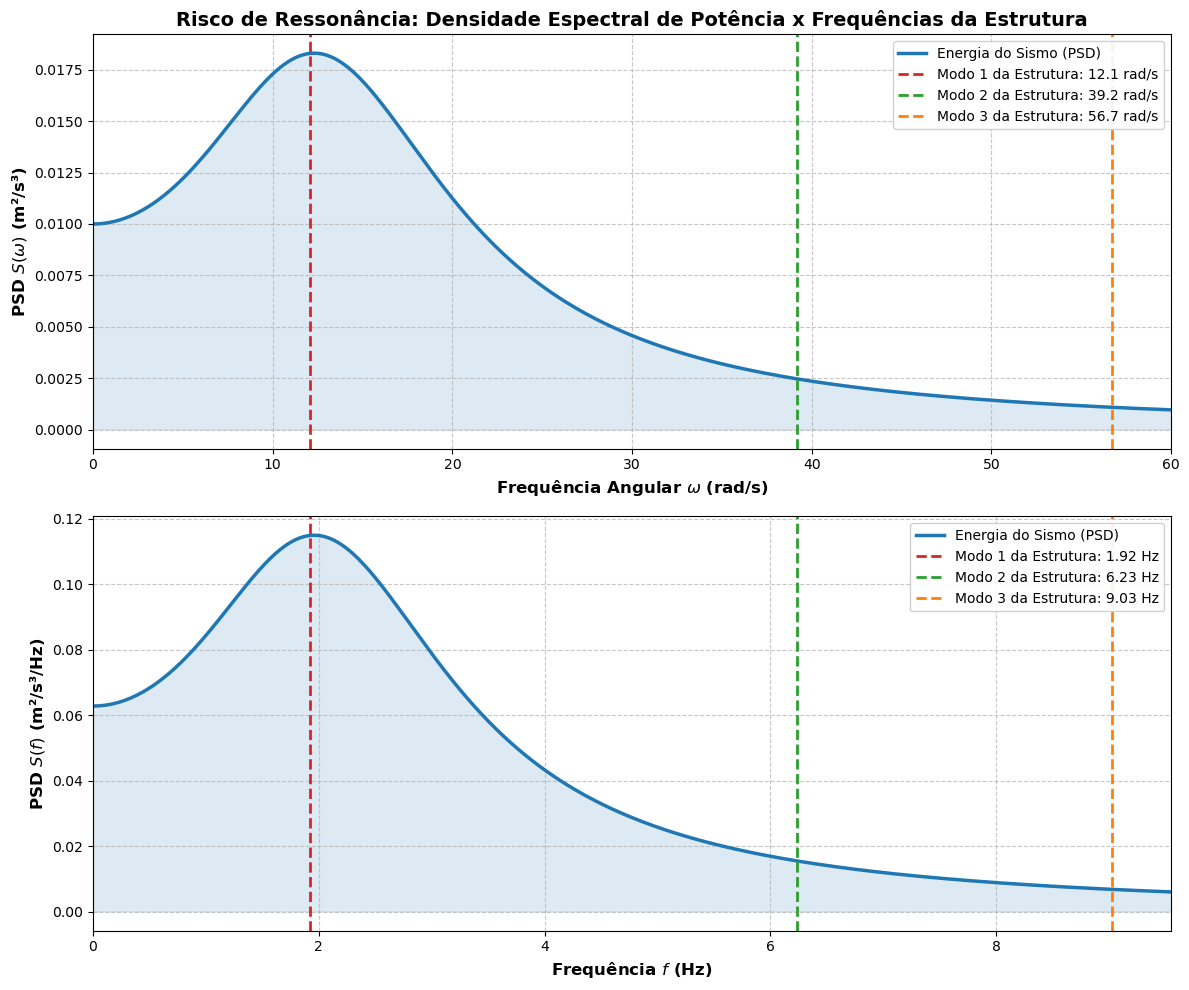

In [22]:
def kanai_tajimi_psd(omega, omega_g, damping_g, S0):
    """
    Calcula a Densidade Espectral de Potência (PSD) do solo.
    omega_g: Frequência predominante do solo (rad/s)
    damping_g: Razão de amortecimento do solo
    S0: Intensidade do ruído branco na base (m²/s³)
    """
    num = omega_g**4 + (2 * damping_g * omega_g * omega)**2
    den = (omega_g**2 - omega**2)**2 + (2 * damping_g * omega_g * omega)**2
    return S0 * (num / den)

# PARÂMETROS EMPÍRICOS DE SOLO (Filtro de Kanai-Tajimi)
# Rocha/Firme: omega_g ~ 25.0-30.0, damping_g ~ 0.2-0.4
# Solo Médio: omega_g ~ 12.0-16.0, damping_g ~ 0.6
# Argila/Mole: omega_g ~ 5.0-10.0, damping_g ~ 0.8-0.85

omega_g = 15.0  # Configurado para Solo Médio/Firme
damping_g = 0.6 
S0 = 0.01       

# Definição do vetor de frequências em rad/s
omega_max = 100.0 
N_freqs = 1000
omega_vec = np.linspace(0.01, omega_max, N_freqs)
S_omega = kanai_tajimi_psd(omega_vec, omega_g, damping_g, S0)

# Conversão rigorosa para o domínio de frequências em Hz
# Pelo princípio da conservação de energia: S(f)df = S(w)dw -> S(f) = S(w) * 2*pi
f_vec = omega_vec / (2 * np.pi)
S_f = S_omega * (2 * np.pi) 

# Criação da figura com dois subplots empilhados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
cores_modos = ['#d62728', '#2ca02c', '#ff7f0e'] # Vermelho, Verde e Laranja para os modos

# GRÁFICO 1: Domínio em rad/s

ax1.plot(omega_vec, S_omega, color='#1f77b4', linewidth=2.5, label='Energia do Sismo (PSD)')
ax1.fill_between(omega_vec, S_omega, color='#1f77b4', alpha=0.15)

# Sobreposição das frequências naturais (rad/s)
# Utilizamos a variável 'omega' já calculada na célula de autovalores
for i, w_n in enumerate(omega[:3]):
    ax1.axvline(w_n, color=cores_modos[i], linestyle='--', linewidth=2, 
                label=f'Modo {i+1} da Estrutura: {w_n:.1f} rad/s')

ax1.set_title("Risco de Ressonância: Densidade Espectral de Potência x Frequências da Estrutura", fontsize=14, weight='bold')
ax1.set_xlabel("Frequência Angular $\\omega$ (rad/s)", fontsize=12, weight='bold')
ax1.set_ylabel("PSD $S(\\omega)$ (m²/s³)", fontsize=12, weight='bold')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xlim(0, 60)
ax1.legend(loc='upper right', framealpha=0.9)

# GRÁFICO 2: Domínio em Hz

ax2.plot(f_vec, S_f, color='#1f77b4', linewidth=2.5, label='Energia do Sismo (PSD)')
ax2.fill_between(f_vec, S_f, color='#1f77b4', alpha=0.15)

# Sobreposição das frequências naturais (Hz)
# Utilizamos a variável 'f_natural' já calculada na célula de autovalores
for i, f_n in enumerate(f_natural[:3]):
    ax2.axvline(f_n, color=cores_modos[i], linestyle='--', linewidth=2, 
                label=f'Modo {i+1} da Estrutura: {f_n:.2f} Hz')

ax2.set_xlabel("Frequência $f$ (Hz)", fontsize=12, weight='bold')
ax2.set_ylabel("PSD $S(f)$ (m²/s³/Hz)", fontsize=12, weight='bold')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_xlim(0, 60 / (2 * np.pi)) # Limite espacial equivalente a 60 rad/s
ax2.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

### GERAÇÃO DE ACELEROGRAMA ARTIFICIAL: MÉTODO DE SHINOZUKA-JAN E ENVELOPE

Para simularmos a resposta estrutural no domínio do tempo (transiente real), nós sintetizamos a PSD em uma série temporal combinando o método de Shinozuka-Jan a um envelope modulador.

**1. Geração do Sinal Estocástico Estacionário**
Nós geramos o sinal somando componentes harmônicas. Determinamos a amplitude da onda via PSD e inserimos uma defasagem de fase estocástica randômica, criando a textura verdadeira de um sismo estacionário.

**2. Modulação Temporal Não-Estacionária (Amin-Ang)**
Para simularmos as fases de chegada, ruptura forte e decaimento sísmico, nós aplicamos o Envelope de Amin-Ang. A multiplicação do sinal por este modulador limita os picos na fase elástica da falha.

**3. Síntese e Representação Gráfica**
Apresentamos o acelerograma integrado, que vai atuar como o vetor de entrada direto nas integrações numéricas seguintes.

**4. Avaliação de Risco de Ressonância (Sobreposição Modal)**
Para atestarmos a vulnerabilidade da estrutura projetada frente ao espectro de solo, nós sobrepomos os três primeiros modos de vibração (calculados na etapa de autovalores) diretamente sobre a curva de densidade energética de Kanai-Tajimi. Se as linhas verticais que representam as frequências da nossa estrutura cruzarem a área de pico da curva azul, confirmamos o alto risco de ressonância dinâmica, indicando que a estrutura irá absorver o máximo de energia destrutiva do sismo. Apresentamos esta análise em dois domínios equivalentes: Frequência Angular (rad/s) e Frequência Cíclica (Hz)."

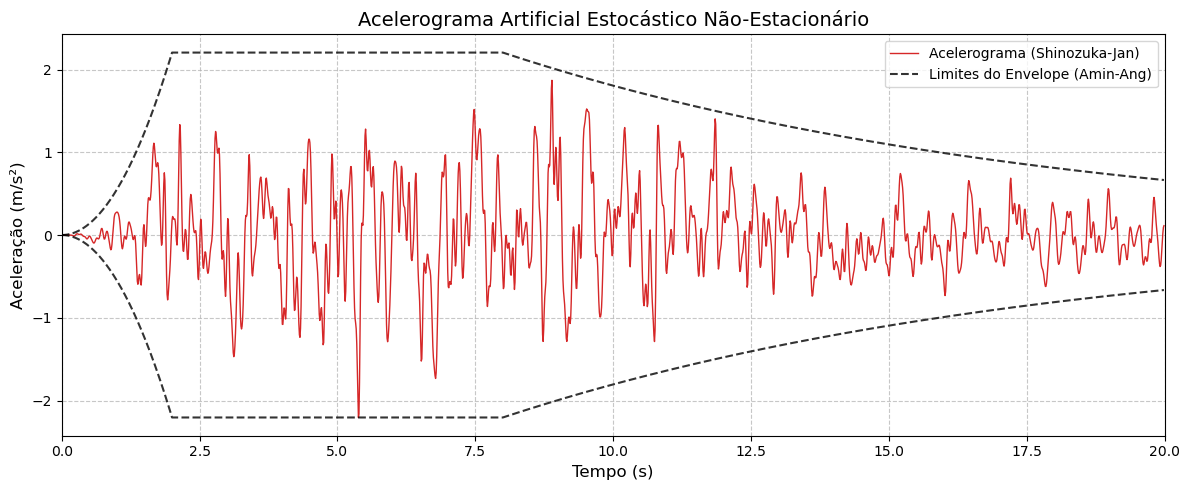

In [23]:
def shinozuka_jan(S_omega, omega, t_max, dt, t1, t2, c_decay):
    """
    Gera acelerograma estocástico não-estacionário via método Shinozuka-Jan,
    aplicando envelope de Amin-Ang para modulação temporal.
    """
    t = np.arange(0, t_max, dt)
    d_omega = omega[1] - omega[0]
    a_t = np.zeros_like(t)
    
    # Semente aleatória (Altere ou remova o valor de seed para gerar sismos diferentes)
    np.random.seed(42)
    phi = np.random.uniform(0, 2*np.pi, len(omega))
    
    for i in range(len(omega)):
        A_i = np.sqrt(2 * S_omega[i] * d_omega)
        a_t += A_i * np.cos(omega[i] * t + phi[i])
        
    envelope = np.ones_like(t)
    for k, tk in enumerate(t):
        if tk < t1:
            envelope[k] = (tk / t1)**2 
        elif tk > t2:
            envelope[k] = np.exp(-c_decay * (tk - t2) / t_max) 
            
    return t, a_t * envelope, envelope

# PARÂMETROS GLOBAIS DO SISMO (Envelope Amin-Ang)
# t1: Fim da fase crescente. t2: Início do decaimento. c_decay: Taxa de queda.
t_max = 20.0      
dt = 0.01         
t1 = 2.0          
t2 = 8.0          
c_decay = 2.0     

tempo, sismo_artificial, envelope = shinozuka_jan(S_omega, omega_vec, t_max, dt, t1, t2, c_decay)

plt.figure(figsize=(12, 5))
plt.plot(tempo, sismo_artificial, color='#d62728', lw=1.0, label='Acelerograma (Shinozuka-Jan)')
max_amp = np.max(np.abs(sismo_artificial))
plt.plot(tempo, envelope * max_amp, color='black', linestyle='--', lw=1.5, alpha=0.8, label='Limites do Envelope (Amin-Ang)')
plt.plot(tempo, -envelope * max_amp, color='black', linestyle='--', lw=1.5, alpha=0.8)
plt.title("Acelerograma Artificial Estocástico Não-Estacionário", fontsize=14)
plt.xlabel("Tempo (s)", fontsize=12)
plt.ylabel("Aceleração (m/s²)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.xlim(0, t_max)
plt.tight_layout()
plt.show()

### MODELAGEM DA DISSIPAÇÃO DE ENERGIA: AMORTECIMENTO DE RAYLEIGH

Para quantificarmos a dissipação viscosa por atrito e microfissuração no nosso solver, nós empregamos o modelo clássico de **Amortecimento de Rayleigh**, criando uma matriz $[C]$ como combinação linear da rigidez e massa.

**1. Formulação do Amortecimento**
Nós definimos $[C_{livre}] = \alpha [M_{livre}] + \beta_R [K_{livre}]$, balanceando dissipação em alta e baixa frequências.

**2. Calibração Modal**
Nós estipulamos uma meta de dissipação de $5\%$ ($0.05$), valor clássico para projetos metálicos e de concreto. Ancoramos esse percentual resolvendo o sistema sobre as duas primeiras frequências fundamentais extraídas nas seções anteriores, isolando algebricamente $\alpha$ e $\beta_R$.

**3. Espectro de Amortecimento**
Geramos a plotagem parabólica clássica de Rayleigh para atestarmos visualmente que os modos fundamentais estão ancorados e as altíssimas frequências sofrerão supressão.

Coeficiente Proporcional à Massa (alpha): 0.9223
Coeficiente Proporcional à Rigidez (beta_R): 0.001952


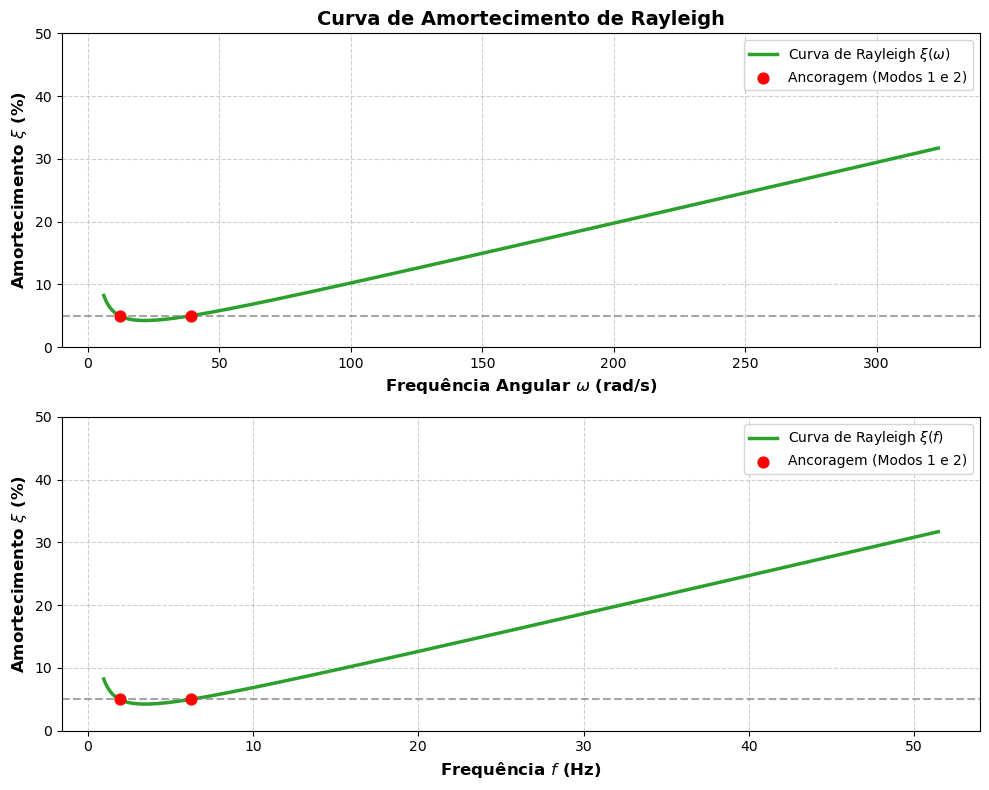

In [24]:
# Taxa de amortecimento modal alvo (5% é padrão estrutural)
xi_target = 0.05 

# Frequências naturais ancoradas nos dois primeiros modos de vibração
w1 = omega[0] 
w2 = omega[1]

A_rayleigh = np.array([[1 / (2 * w1), w1 / 2],
                       [1 / (2 * w2), w2 / 2]])
b_rayleigh = np.array([xi_target, xi_target])

alpha, beta_R = np.linalg.solve(A_rayleigh, b_rayleigh)

print(f"Coeficiente Proporcional à Massa (alpha): {alpha:.4f}")
print(f"Coeficiente Proporcional à Rigidez (beta_R): {beta_R:.6f}")

# Criação da matriz de amortecimento reduzida
C_livre = alpha * M_livre + beta_R * Kg_livre

# Ajuste do domínio de plotagem para focar na região de interesse estrutural.
# Começamos em 50% de w1 para evitar o disparo matemático do termo 1/w próximo a zero.
w_max_plot = omega[min(10, len(omega)-1)]
omega_plot = np.linspace(0.5 * w1, 1.2 * w_max_plot, 500)
xi_plot = 0.5 * (alpha / omega_plot + beta_R * omega_plot)

# Vetores equivalentes em Hz
f_plot = omega_plot / (2 * np.pi)
f1 = w1 / (2 * np.pi)
f2 = w2 / (2 * np.pi)

# Criação da figura com dois subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

# GRÁFICO 1: Domínio em rad/s

ax1.plot(omega_plot, xi_plot * 100, color='#2ca02c', linewidth=2.5, label='Curva de Rayleigh $\\xi(\\omega)$')
ax1.scatter([w1, w2], [xi_target * 100, xi_target * 100], color='red', s=60, zorder=5, label='Ancoragem (Modos 1 e 2)')
ax1.axhline(xi_target * 100, color='gray', linestyle='--', alpha=0.7)
ax1.set_title("Curva de Amortecimento de Rayleigh", fontsize=14, weight='bold')
ax1.set_xlabel("Frequência Angular $\\omega$ (rad/s)", fontsize=12, weight='bold')
ax1.set_ylabel("Amortecimento $\\xi$ (%)", fontsize=12, weight='bold')
ax1.set_ylim(0, 50) # Travando o eixo Y em 50% para legibilidade de engenharia
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')

# GRÁFICO 2: Domínio em Hz

ax2.plot(f_plot, xi_plot * 100, color='#2ca02c', linewidth=2.5, label='Curva de Rayleigh $\\xi(f)$')
ax2.scatter([f1, f2], [xi_target * 100, xi_target * 100], color='red', s=60, zorder=5, label='Ancoragem (Modos 1 e 2)')
ax2.axhline(xi_target * 100, color='gray', linestyle='--', alpha=0.7)
ax2.set_xlabel("Frequência $f$ (Hz)", fontsize=12, weight='bold')
ax2.set_ylabel("Amortecimento $\\xi$ (%)", fontsize=12, weight='bold')
ax2.set_ylim(0, 50) # Travando o eixo Y em 50%
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### ANÁLISE DINÂMICA NO DOMÍNIO DO TEMPO: INTEGRAÇÃO NUMÉRICA DE NEWMARK

Aqui nós adentramos o motor de resolução transiente. Empregamos o algoritmo iterativo de **Newmark** (esquema da Aceleração Média), incondicionalmente estável, para mapearmos deslocamentos, velocidades e acelerações ao longo de todo o sismo.

**1. Matriz Efetiva e Fatoração de Cholesky**
Montamos a Matriz de Rigidez Efetiva pseudoestática ($[K_{eff}]$). Como estamos no regime linear (propriedades constantes), para economizarmos um volume maciço de processamento em cada iteração, nós aplicamos de cara a **Fatoração de Cholesky**, convertendo inversões onerosas em rápidas retro-substituições triangulares.

**2. Resolução Iterativa**
Nós executamos um laço no domínio do tempo, integrando as equações de predição-correção com vetores de força efetivos atualizados. Ao fim, reintroduzimos os graus de restrição para calcularmos as acelerações nodais absolutas.

**3. Vetores de Influência Multidirecionais**
Nós expomos a estrutura a 3 frentes de ataque do sismo:
* **Incidência Horizontal (Eixo X)**
* **Incidência Vertical (Eixo Y)**
* **Incidência Oblíqua (45°)**: Simula a componente bidirecional gravíssima.

In [25]:
from scipy.linalg import cho_factor, cho_solve

# Método de Newmark da Aceleração Média Incondicionalmente Estável
gamma = 0.5
beta = 0.25 

a0 = 1 / (beta * dt**2)
a1 = gamma / (beta * dt)
a2 = 1 / (beta * dt)
a3 = 1 / (2 * beta) - 1
a4 = gamma / beta - 1
a5 = dt / 2 * (gamma / beta - 2)
a6 = dt * (1 - gamma)
a7 = gamma * dt

# Matriz Efetiva Estática
K_eff = Kg_livre + a0 * M_livre + a1 * C_livre

# Fatoração primária (Alta otimização, computado apenas uma vez)
c_and_lower = cho_factor(K_eff)

N_steps = len(tempo)
N_dofs = len(gdl_livres)

def aplica_sismo_newmark(I_vec):
    """ Resolve iterativamente equação de movimento dado um vetor de influência topológica. """
    I_livre = I_vec[gdl_livres]
    F_eff = -M_livre @ I_livre 

    U = np.zeros((N_dofs, N_steps)) 
    V = np.zeros((N_dofs, N_steps)) 
    A = np.zeros((N_dofs, N_steps)) 

    F_0 = F_eff * sismo_artificial[0]
    A[:, 0] = np.linalg.solve(M_livre, F_0)

    for i in range(N_steps - 1):
        P_i1 = F_eff * sismo_artificial[i+1]
        P_eff_step = P_i1 + M_livre @ (a0 * U[:, i] + a2 * V[:, i] + a3 * A[:, i]) + \
                            C_livre @ (a1 * U[:, i] + a4 * V[:, i] + a5 * A[:, i])
        
        U[:, i+1] = cho_solve(c_and_lower, P_eff_step)
        A[:, i+1] = a0 * (U[:, i+1] - U[:, i]) - a2 * V[:, i] - a3 * A[:, i]
        V[:, i+1] = V[:, i] + a6 * A[:, i] + a7 * A[:, i+1]

    # Expansão para incluir as condições de contorno de volta ao vetor
    U_tot = np.zeros((maxgdl, N_steps))
    A_tot = np.zeros((maxgdl, N_steps))
    U_tot[gdl_livres, :] = U
    A_tot[gdl_livres, :] = A

    # Cálculo Aceleração Absoluta = Aceleração Relativa + Aceleração Base
    A_abs = np.zeros_like(A_tot)
    for i in range(N_steps):
        A_abs[0::2, i] = A_tot[0::2, i] + I_vec[0::2] * sismo_artificial[i]
        A_abs[1::2, i] = A_tot[1::2, i] + I_vec[1::2] * sismo_artificial[i]

    return U_tot, A_abs

print(f"Iniciando integração de Newmark ({N_steps} iterações em 3 cenários dimensionais)...\n")

I_X = np.zeros(maxgdl)
I_X[0::2] = 1.0  
U_X, A_X = aplica_sismo_newmark(I_X)
print("✅ Cenário Direção X concluído.")

I_Y = np.zeros(maxgdl)
I_Y[1::2] = 1.0  
U_Y, A_Y = aplica_sismo_newmark(I_Y)
print("✅ Cenário Direção Y concluído.")

I_45 = np.zeros(maxgdl)
angulo = np.radians(45)
I_45[0::2] = np.cos(angulo) 
I_45[1::2] = np.sin(angulo) 
U_45, A_45 = aplica_sismo_newmark(I_45)
print("✅ Cenário Incidência a 45° concluído.\n")

print("Módulo de Análise Dinâmica 100% Finalizado.")

Iniciando integração de Newmark (2000 iterações em 3 cenários dimensionais)...

✅ Cenário Direção X concluído.
✅ Cenário Direção Y concluído.
✅ Cenário Incidência a 45° concluído.

Módulo de Análise Dinâmica 100% Finalizado.


### PÓS-PROCESSAMENTO DOS RESULTADOS: MAPEAMENTO DE VULNERABILIDADE E NÓS CRÍTICOS

De posse do comportamento em campo da estrutura, nós consolidamos os dados extraindo a envoltória cinemática de picos por nó, em 3 processos fundamentais:

**1. Processamento Cinemático**
Nós computamos a componente euclidiana contínua ($R = \sqrt{x^2 + y^2}$) extraindo o deslocamento máximo real em mm, e a aceleração máxima absoluta em função da gravidade (g).

**2. Ranqueamento de Severidade**
Nós elaboramos matrizes tabulares aplicando colorações de fundo (heatmaps numéricos) que disparam aos olhos do projetista imediatamente o top-10 de nós mais vulneráveis no *drift* lateral e vertical.

**3. Renderização Espacial de Mapa de Calor**
Finalmente, renderizamos diagramas mapeando a vulnerabilidade física diretamente sobre o arcabouço inercial da estrutura, apontando nominalmente com balões em amarelo os pontos que demandarão verificação severa de norma.


⚠️ RANKING DOS 10 NÓS MAIS CRÍTICOS - Sismo Direção X


Posição,Nó,X (m),Y (m),Máx Deslocamento Resultante (mm),Máx Aceleração Resultante (g)
1,2,9.75,30.00,41.68,0.67
2,1,-5.25,30.00,41.68,0.68
3,5,6.75,30.00,38.84,0.61
4,3,-2.25,30.00,38.82,0.61
5,7,3.75,30.00,37.40,0.58
6,6,0.75,30.00,37.37,0.58
7,4,-2.25,28.50,35.25,0.55
8,8,6.75,28.50,35.25,0.55
9,11,3.75,27.00,30.06,0.45
10,10,0.75,27.00,30.05,0.45


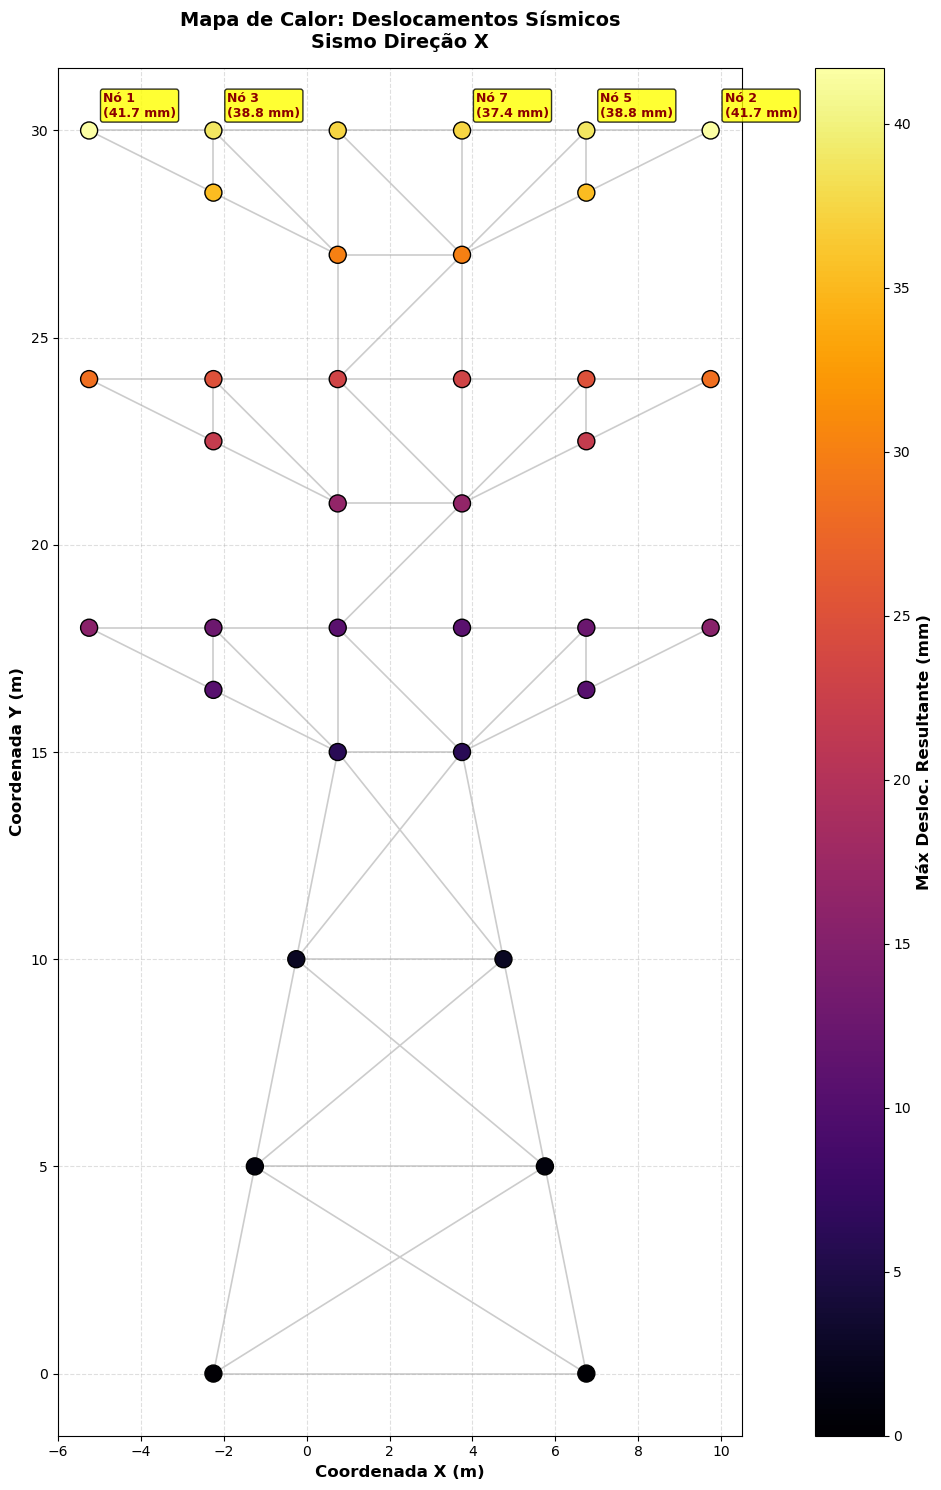


⚠️ RANKING DOS 10 NÓS MAIS CRÍTICOS - Sismo Direção Y


Posição,Nó,X (m),Y (m),Máx Deslocamento Resultante (mm),Máx Aceleração Resultante (g)
1,1,-5.25,30.00,0.85,0.37
2,2,9.75,30.00,0.81,0.34
3,9,-5.25,24.00,0.80,0.34
4,12,9.75,24.00,0.71,0.32
5,15,-5.25,18.00,0.68,0.30
6,36,9.75,18.00,0.56,0.30
7,4,-2.25,28.50,0.54,0.27
8,3,-2.25,30.00,0.54,0.27
9,5,6.75,30.00,0.53,0.26
10,8,6.75,28.50,0.52,0.26


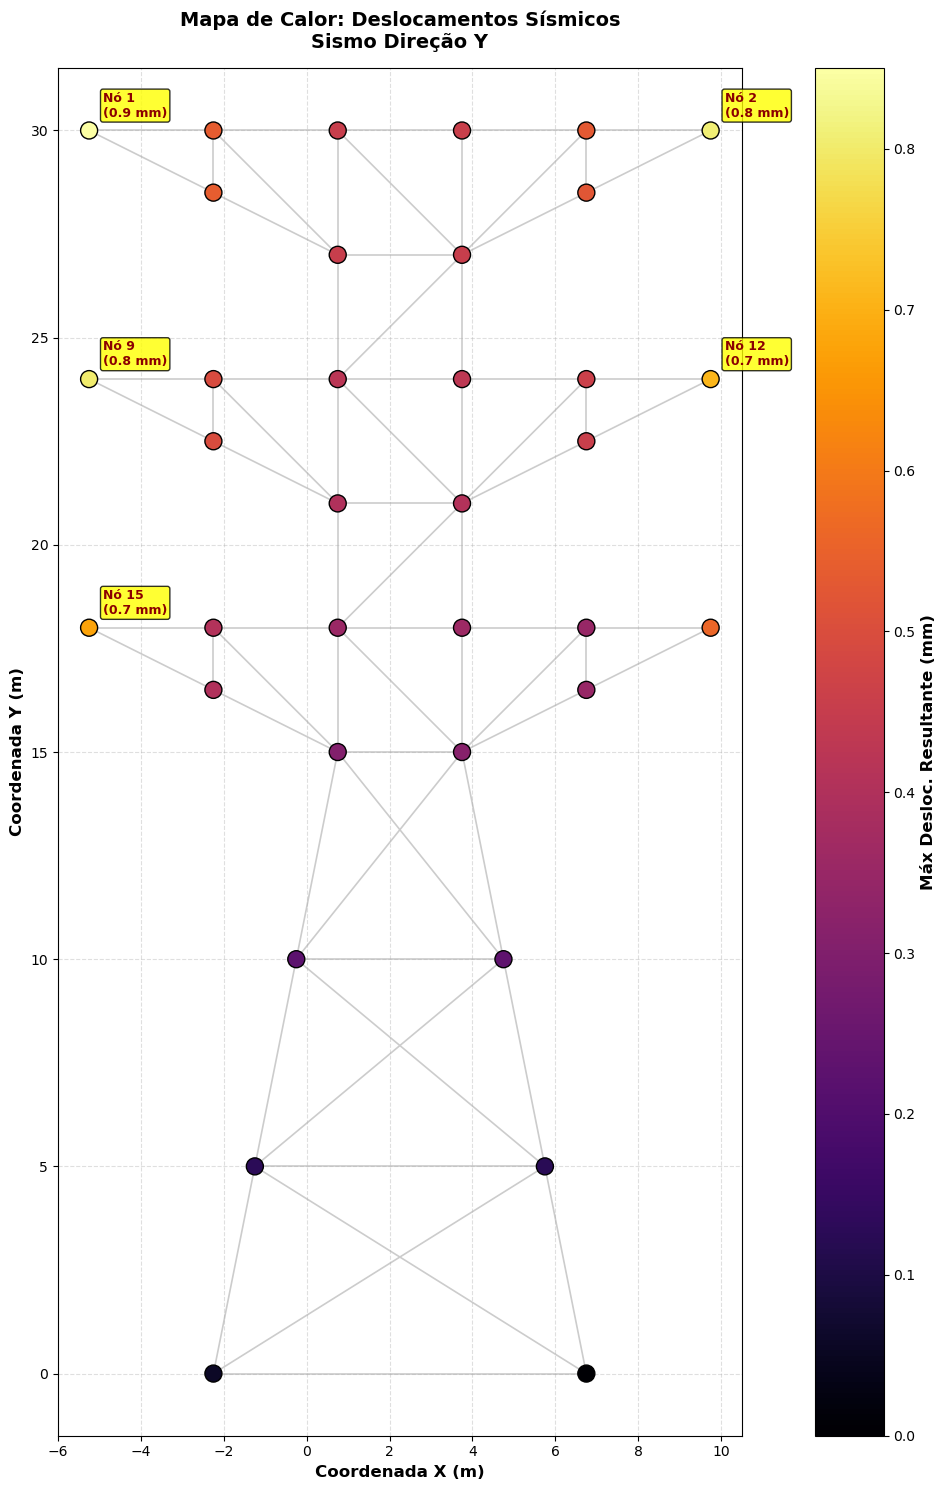


⚠️ RANKING DOS 10 NÓS MAIS CRÍTICOS - Sismo a 45°


Posição,Nó,X (m),Y (m),Máx Deslocamento Resultante (mm),Máx Aceleração Resultante (g)
1,1,-5.25,30.00,29.63,0.52
2,2,9.75,30.00,29.55,0.48
3,3,-2.25,30.00,27.57,0.45
4,5,6.75,30.00,27.55,0.43
5,7,3.75,30.00,26.54,0.41
6,6,0.75,30.00,26.52,0.42
7,4,-2.25,28.50,25.02,0.39
8,8,6.75,28.50,25.00,0.39
9,11,3.75,27.00,21.32,0.32
10,10,0.75,27.00,21.32,0.31


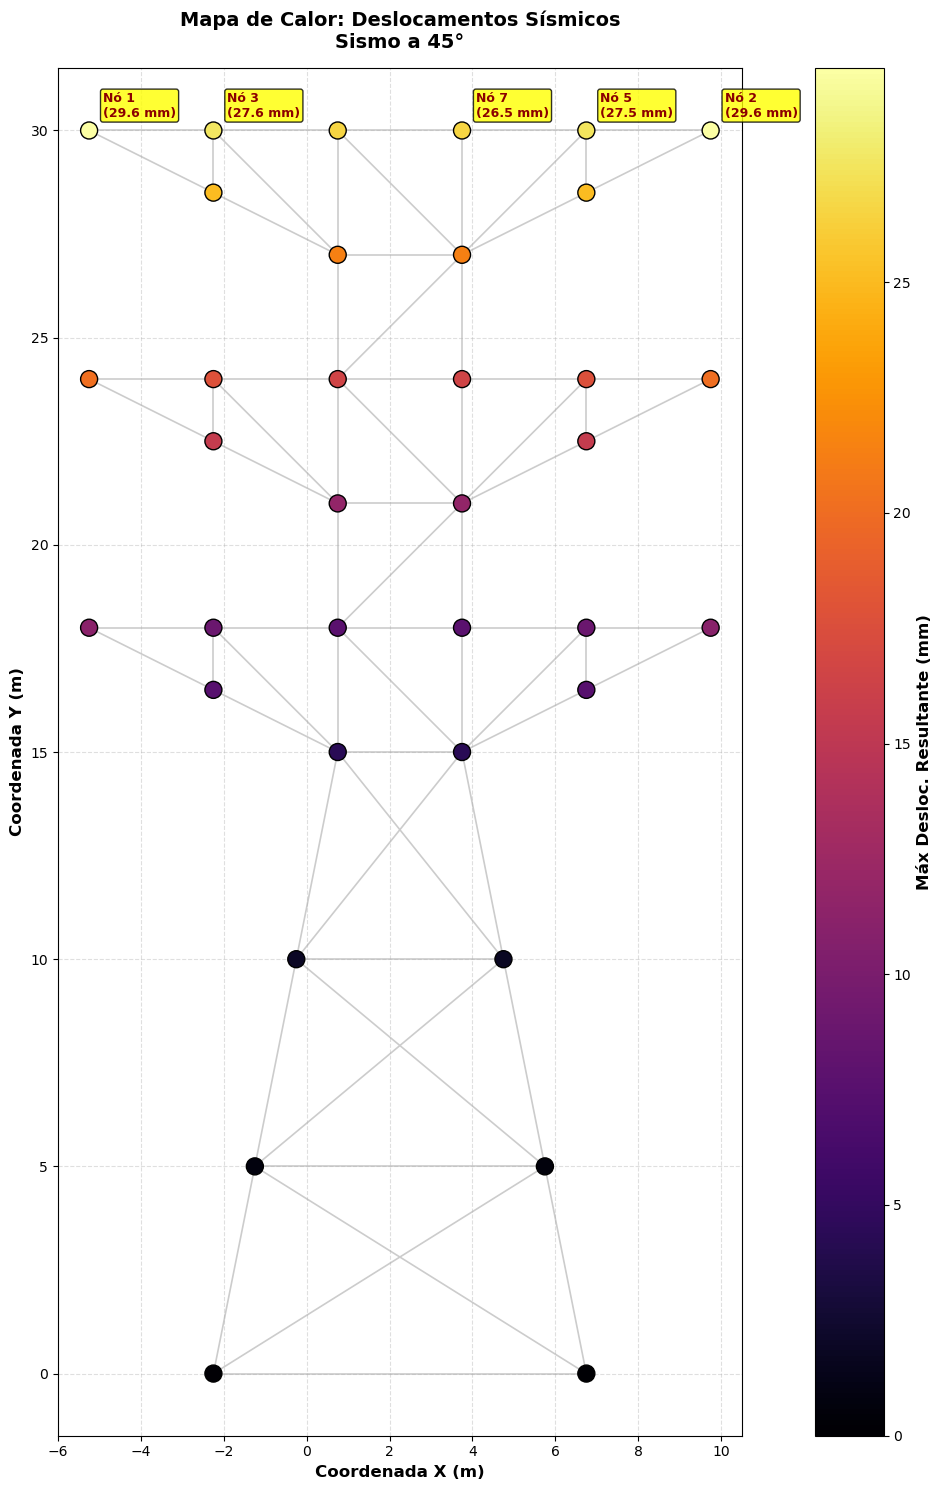

In [26]:
def analisar_e_plotar_ranking(U_cenario, A_cenario, nome_cenario):
    ranking_dados = []
    g = 9.81 

    for i, row in enumerate(nos.itertuples()):
        no_id = row.Index
        X, Y = row.X, row.Y
        
        idx_x = 2 * i
        idx_y = 2 * i + 1
        
        dx_t = U_cenario[idx_x, :] * 1000  
        dy_t = U_cenario[idx_y, :] * 1000  
        
        d_resultante = np.sqrt(dx_t**2 + dy_t**2)
        max_d = np.max(d_resultante)
        
        ax_g = A_cenario[idx_x, :] / g
        ay_g = A_cenario[idx_y, :] / g
        max_a = np.max(np.sqrt(ax_g**2 + ay_g**2))
        
        ranking_dados.append({
            'Nó': int(no_id),
            'X (m)': X,
            'Y (m)': Y,
            'Máx Deslocamento Resultante (mm)': max_d,
            'Máx Aceleração Resultante (g)': max_a
        })

    df_ranking = pd.DataFrame(ranking_dados)
    df_ranking_sorted = df_ranking.sort_values(by='Máx Deslocamento Resultante (mm)', ascending=False).reset_index(drop=True)
    df_ranking_sorted.insert(0, 'Posição', np.arange(1, len(df_ranking_sorted) + 1))

    print(f"\n⚠️ RANKING DOS 10 NÓS MAIS CRÍTICOS - {nome_cenario}")
    
    display(df_ranking_sorted.head(10).style.hide(axis="index")
                           .background_gradient(cmap='Reds', subset=['Máx Deslocamento Resultante (mm)', 'Máx Aceleração Resultante (g)'])
                           .format("{:.2f}", subset=['X (m)', 'Y (m)', 'Máx Deslocamento Resultante (mm)', 'Máx Aceleração Resultante (g)']))

    # Mapeamento Espacial 
    plt.figure(figsize=(15, 15))
    plt.title(f'Mapa de Calor: Deslocamentos Sísmicos\n{nome_cenario}', fontsize=14, weight='bold', pad=15)

    for row in barras.itertuples():
        xi, yi = nos.loc[row.NI, ['X', 'Y']]
        xf, yf = nos.loc[row.NF, ['X', 'Y']]
        plt.plot([xi, xf], [yi, yf], color='#cccccc', linestyle='-', linewidth=1.2, zorder=1)

    scatter = plt.scatter(df_ranking['X (m)'], df_ranking['Y (m)'], 
                          c=df_ranking['Máx Deslocamento Resultante (mm)'], 
                          s=150, cmap='inferno', edgecolors='black', zorder=3)

    cbar = plt.colorbar(scatter)
    cbar.set_label('Máx Desloc. Resultante (mm)', fontsize=12, weight='bold')

    top_5 = df_ranking_sorted.head(5)
    for _, row in top_5.iterrows():
        plt.annotate(f"Nó {int(row['Nó'])}\n({row['Máx Deslocamento Resultante (mm)']:.1f} mm)", 
                     xy=(row['X (m)'], row['Y (m)']), xytext=(10, 10),
                     textcoords='offset points', fontsize=9, weight='bold', color='darkred',
                     bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.8, ec="black"), zorder=4)

    plt.xlabel('Coordenada X (m)', fontsize=12, weight='bold')
    plt.ylabel('Coordenada Y (m)', fontsize=12, weight='bold')
    plt.gca().set_aspect('equal')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

analisar_e_plotar_ranking(U_X, A_X, "Sismo Direção X")
analisar_e_plotar_ranking(U_Y, A_Y, "Sismo Direção Y")
analisar_e_plotar_ranking(U_45, A_45, "Sismo a 45°")

### PÓS-PROCESSAMENTO DOS RESULTADOS: ENVOLTÓRIA DE ESFORÇOS AXIAIS NAS BARRAS

Para avaliarmos a capacidade resistente das seções, nós traduzimos a resposta cinemática em esforços dinâmicos puros de tração e compressão das barras ao longo do eixo do tempo.

**1. Transformação Cinemática**
Nós usamos o vetor e a rigidez $N(t) = \frac{EA}{L} [-c, -s, c, s] \cdot \{u(t)\}$ para computar todo o histórico oscilatório (sismo induz flexão constante de sinais).

**2. Extração de Envoltória de Pico Dinâmico**
Nós isolamos apenas a coordenada máxima absoluta, respeitando rigorosamente o sinal algébrico final. Queremos ter certeza se a solicitação crítica da barra ocorreu em tração franca ou durante um evento de compressão (trazendo consigo as instabilidades de flambagem local e global).

**3. Representação Gráfica Padrão**
Nós mantemos a mesma formatação estipulada em módulos estáticos de software estrutural: Vermelho (Tração), Azul (Compressão) e Preto (Nulo). Alinhamos os textos algebricamente usando o arco-tangente.

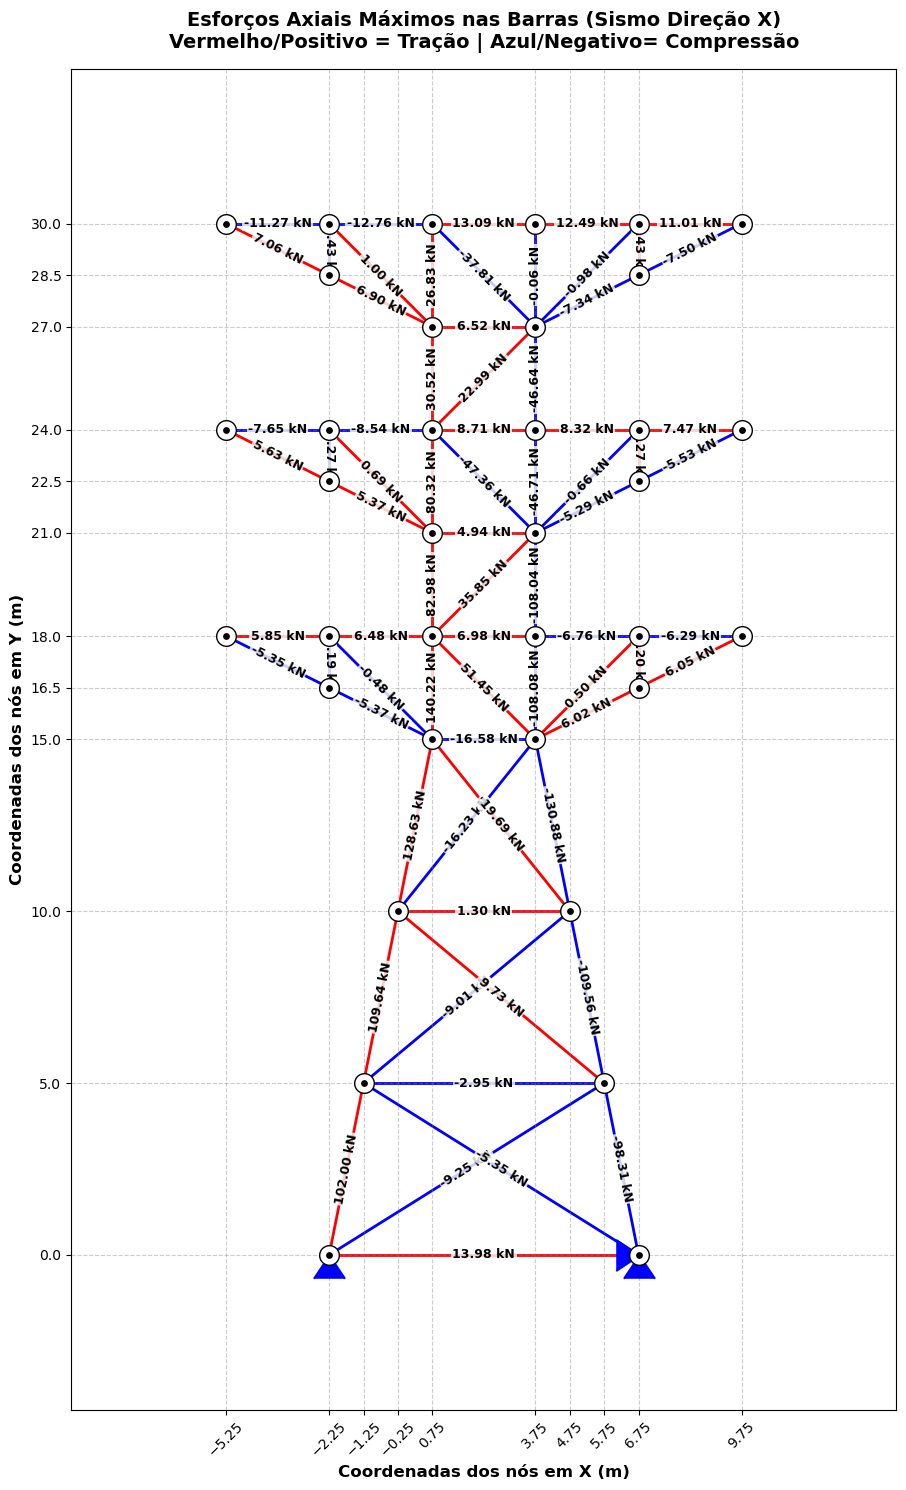

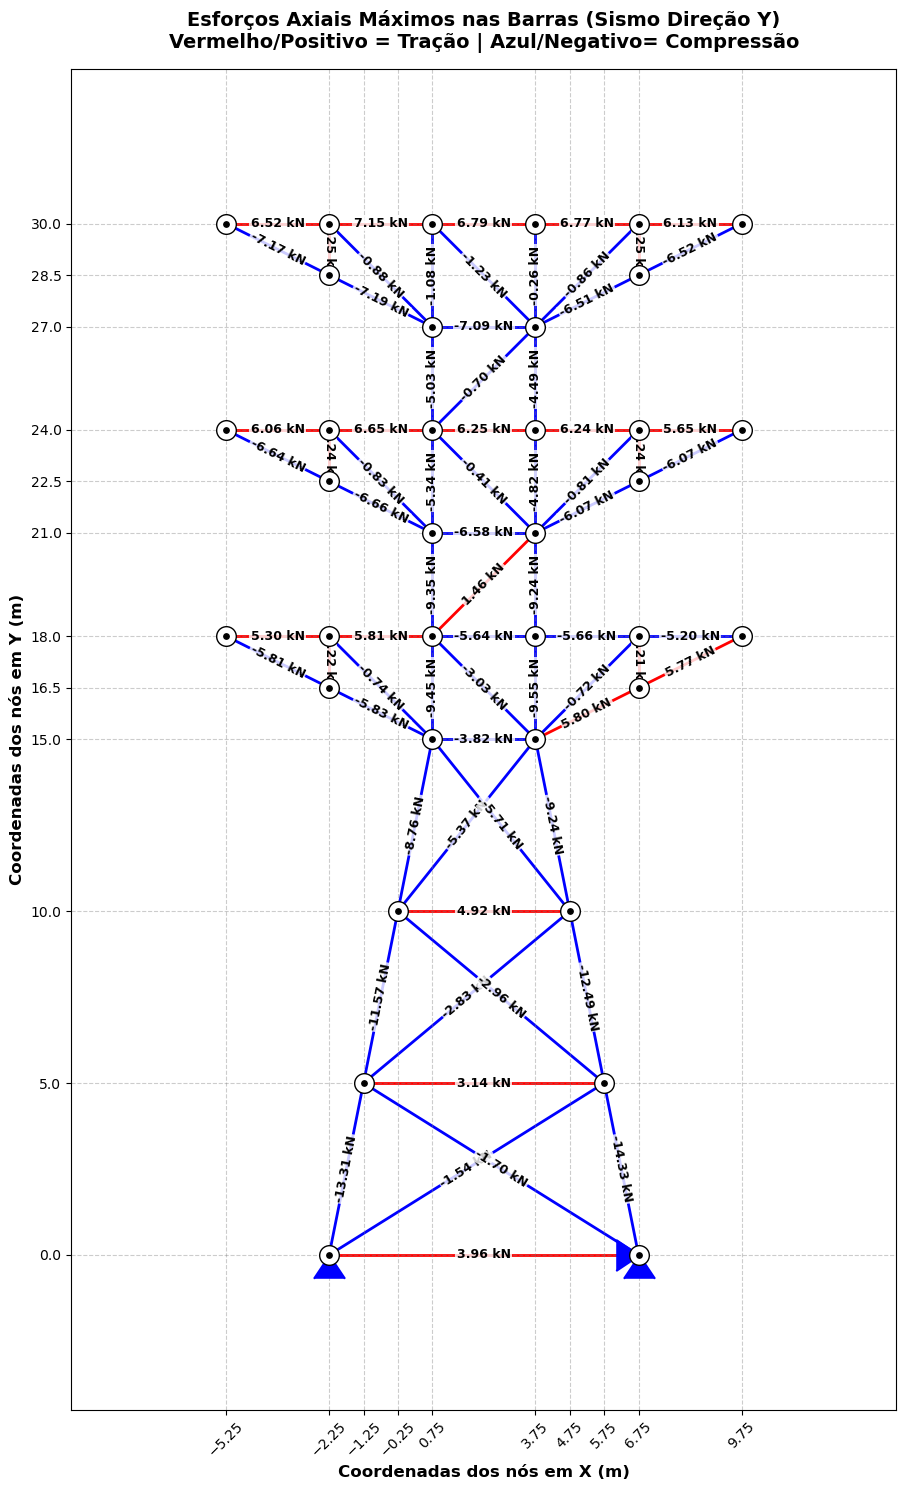

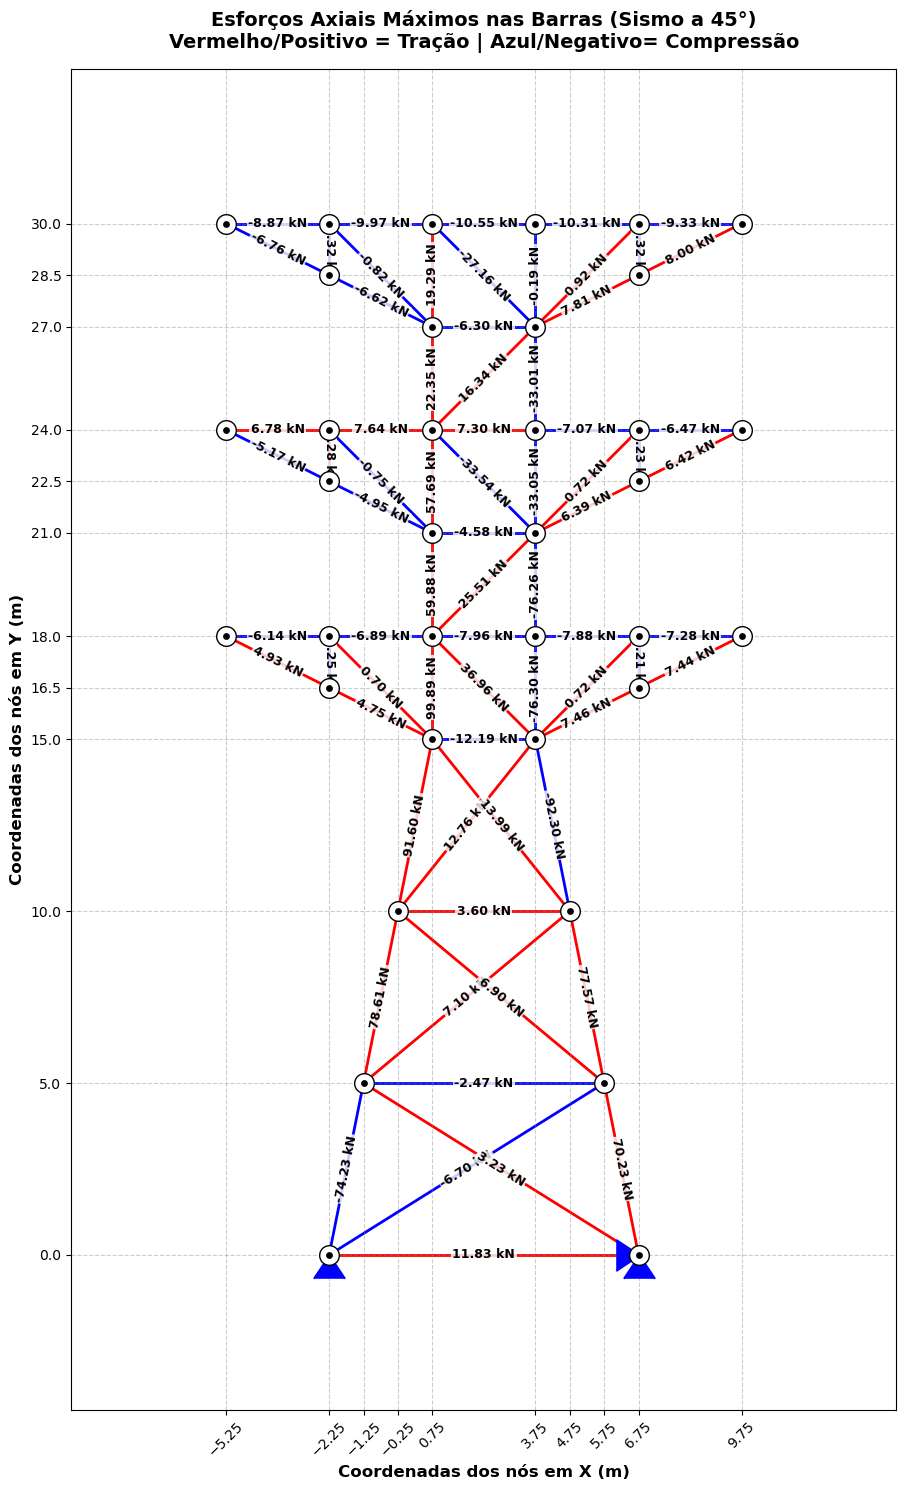

In [27]:
def plotar_esforcos_estilo_original(U_cenario, nome_cenario):
    mapa_nos = {row.Index: i for i, row in enumerate(nos.itertuples())}
    
    plt.figure(figsize=(15, 15))
    plt.title(f'Esforços Axiais Máximos nas Barras ({nome_cenario})\nVermelho/Positivo = Tração | Azul/Negativo= Compressão', fontsize=14, weight='bold', pad=15)

    for row in barras.itertuples(): 
        barra_id = row.Index
        NI, NF = row.NI, row.NF
        A, E = row.A, row.E
        
        xi, yi = nos.loc[NI, ['X', 'Y']]
        xf, yf = nos.loc[NF, ['X', 'Y']]
        
        L = np.sqrt((xf - xi)**2 + (yf - yi)**2)
        c, s = (xf - xi) / L, (yf - yi) / L
        
        pos_ni, pos_nf = mapa_nos[NI], mapa_nos[NF]
        idx = [2*pos_ni, 2*pos_ni+1, 2*pos_nf, 2*pos_nf+1]
        
        u_t = U_cenario[idx, :]
        T = np.array([-c, -s, c, s])
        
        N_t = (E * A / L) * np.dot(T, u_t) / 1000.0
        
        idx_max_abs = np.argmax(np.abs(N_t))
        ESF_val = N_t[idx_max_abs] 
        
        dy, dx = yf - yi, xf - xi
        ANG = np.degrees(np.arctan2(dy, dx))
        if ANG > 90:
            ANG -= 180
        elif ANG < -90:
            ANG += 180
        
        if abs(ESF_val) < 1e-4: 
            cor = 'k' 
        elif ESF_val > 0:
            cor = 'r' 
        else: 
            cor = 'b' 
            
        plt.plot([xi, xf], [yi, yf], color=cor, zorder=1, linewidth=2)

        plt.text(np.mean([xi, xf]), np.mean([yi, yf]),
                 f'{ESF_val:.2f} kN',
                 rotation=ANG,
                 horizontalalignment='center',
                 verticalalignment='center',
                 size=9,
                 weight='bold',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1),
                 zorder=2)
    
    for row in nos.itertuples(): 
        X, Y, RX, RY = row.X, row.Y, row.RX, row.RY
     
        plt.scatter(X, Y, s=200, c='white', edgecolors='black', marker='o', zorder=3)
        plt.scatter(X, Y, s=15, c='black', marker='o', zorder=4)
        
        if RX == 1: plt.scatter(X, Y, s=500, color='blue', marker=5, zorder=2) 
        if RY == 1: plt.scatter(X, Y, s=500, color='blue', marker=6, zorder=2) 

    coordenadas_x = nos['X'].unique()
    coordenadas_y = nos['Y'].unique()

    plt.xlabel('Coordenadas dos nós em X (m)', fontsize=12, weight='bold')
    plt.ylabel('Coordenadas dos nós em Y (m)', fontsize=12, weight='bold')
    plt.xticks(coordenadas_x, rotation=45)
    plt.yticks(coordenadas_y)
    plt.grid(visible=True, which='major', color='gray', linestyle='--', alpha=0.4, zorder=-2)

    dim_ref = max(nos['X'].max() - nos['X'].min(), nos['Y'].max() - nos['Y'].min())
    if dim_ref == 0: dim_ref = 1.0
    margem = dim_ref * 0.15
    plt.xlim(coordenadas_x.min() - margem, coordenadas_x.max() + margem)
    plt.ylim(coordenadas_y.min() - margem, coordenadas_y.max() + margem)

    plt.gca().set_aspect('equal')
    plt.tight_layout() 
    plt.show()

plotar_esforcos_estilo_original(U_X, "Sismo Direção X")
plotar_esforcos_estilo_original(U_Y, "Sismo Direção Y")
plotar_esforcos_estilo_original(U_45, "Sismo a 45°")

### SÍNTESE DE ESFORÇOS E COMBINAÇÕES DE PROJETO (ENVOLTÓRIA)

Para consolidarmos as verificações de projeto, nós extraímos os parâmetros finais de dimensionamento valendo-nos da superposição de efeitos mecânicos.

**1. Extração de Demandas Isoladas**
O algoritmo passa um último pente fino na dinâmica do tempo ($N(t)$) para extrairmos a verdadeira magnitude isolada de pico.

**2. Superposição Linear**
O modelo está calcado no regime elástico-linear, então nós simplesmente superpomos o esforço estático gravitacional ($N_{estático}$) e os picos dinâmicos computados, construindo colunas modulares para os picos de cada incidência sísmica.

**3. Tabulação Visual**
Nós injetamos diretamente formatações CSS de negrito e cores (Vermelho e Azul) para garantirmos a fluidez da leitura, transformando nossa saída num documento direto, limpo e à prova de ambiguidades para a equipe de detalhamento.

In [28]:
# Tabela Síntese de Esforços (Envoltória Estático + Dinâmico corrigida no domínio do tempo)
mapa_nos = {row.Index: i for i, row in enumerate(nos.itertuples())}

esf_din_pico_X, esf_din_pico_Y, esf_din_pico_45 = [], [], []
comb_X_max, comb_X_min = [], []
comb_Y_max, comb_Y_min = [], []
comb_45_max, comb_45_min = [], []

for row in barras.itertuples():
    NI, NF = row.NI, row.NF
    A, E, L = row.A, row.E, row.L
    N_est = row.ESF / 1000.0  # Esforço estático (kN) já contendo peso próprio
    
    xi, yi = nos.loc[NI, ['X', 'Y']]
    xf, yf = nos.loc[NF, ['X', 'Y']]
    c, s = (xf - xi) / L, (yf - yi) / L
    
    pos_ni, pos_nf = mapa_nos[NI], mapa_nos[NF]
    idx = [2*pos_ni, 2*pos_ni+1, 2*pos_nf, 2*pos_nf+1]
    T = np.array([-c, -s, c, s])
    
    def extrair_combinacao_tempo(U_cenario):
        u_t = U_cenario[idx, :]
        N_din_t = (E * A / L) * np.dot(T, u_t) / 1000.0 # Histórico dinâmico (kN)
        
        # Superposição real no domínio do tempo: N_total(t) = N_estatico + N_dinamico(t)
        N_tot_t = N_est + N_din_t
        
        # Pico absoluto dinâmico (apenas para registro/avaliação do sismo isolado)
        idx_max_abs = np.argmax(np.abs(N_din_t))
        pico_din = N_din_t[idx_max_abs]
        
        # Envoltória real da barra neste cenário (Tração máxima e Compressão máxima)
        return pico_din, np.max(N_tot_t), np.min(N_tot_t)
    
    pico_x, max_x, min_x = extrair_combinacao_tempo(U_X)
    pico_y, max_y, min_y = extrair_combinacao_tempo(U_Y)
    pico_45, max_45, min_45 = extrair_combinacao_tempo(U_45)
    
    esf_din_pico_X.append(pico_x)
    comb_X_max.append(max_x)
    comb_X_min.append(min_x)
    
    esf_din_pico_Y.append(pico_y)
    comb_Y_max.append(max_y)
    comb_Y_min.append(min_y)
    
    esf_din_pico_45.append(pico_45)
    comb_45_max.append(max_45)
    comb_45_min.append(min_45)

df_combos = pd.DataFrame({
    'Barra': barras.index,
    'Nó Inicial': barras['NI'],
    'Nó Final': barras['NF'],
    'L (m)': np.round(barras['L'], 2),
    'Estático (kN)': barras['ESF'] / 1000.0,
    'Pico Din. X': esf_din_pico_X,
    'Comb. X (Máx)': comb_X_max,
    'Comb. X (Mín)': comb_X_min,
    'Comb. Y (Máx)': comb_Y_max,
    'Comb. Y (Mín)': comb_Y_min,
    'Comb. 45° (Máx)': comb_45_max,
    'Comb. 45° (Mín)': comb_45_min
})

def colorir_tracao_compressao(val):
    if isinstance(val, (int, float)):
        if val > 1e-4: return 'color: #d62728; font-weight: bold;' 
        elif val < -1e-4: return 'color: #1f77b4; font-weight: bold;' 
    return 'color: black;'

colunas_esforcos = ['Estático (kN)', 'Pico Din. X', 'Comb. X (Máx)', 'Comb. X (Mín)', 
                    'Comb. Y (Máx)', 'Comb. Y (Mín)', 'Comb. 45° (Máx)', 'Comb. 45° (Mín)']

print("\nTABELA DE COMBINAÇÕES DE ESFORÇOS AXIAIS (SUPERPOSIÇÃO NO TEMPO)\n")
display(df_combos.style.hide(axis="index")
                 .map(colorir_tracao_compressao, subset=colunas_esforcos)
                 .format("{:.2f}", subset=colunas_esforcos))


TABELA DE COMBINAÇÕES DE ESFORÇOS AXIAIS (SUPERPOSIÇÃO NO TEMPO)



Barra,Nó Inicial,Nó Final,L (m),Estático (kN),Pico Din. X,Comb. X (Máx),Comb. X (Mín),Comb. Y (Máx),Comb. Y (Mín),Comb. 45° (Máx),Comb. 45° (Mín)
1,17,16,9.000000,14.95,13.98,28.94,1.84,18.91,11.34,26.78,4.06
2,17,26,5.100000,-51.45,102.00,50.56,-153.09,-39.32,-64.76,21.98,-125.68
3,17,25,9.430000,-5.74,-9.25,2.72,-14.99,-4.24,-7.28,0.35,-12.44
4,16,26,9.430000,-5.74,-5.35,-1.09,-11.09,-4.23,-7.44,-2.51,-8.80
5,16,25,5.100000,-51.45,-98.31,46.12,-149.76,-39.37,-65.78,18.78,-120.78
6,26,25,7.000000,11.30,-2.95,14.04,8.35,14.44,8.65,13.57,8.83
7,26,31,5.100000,-43.74,109.64,65.90,-151.52,-33.36,-55.31,34.87,-121.31
8,26,30,7.810000,-10.34,-9.01,-2.06,-19.34,-7.53,-13.16,-3.24,-17.27
9,25,31,7.810000,-10.34,9.73,-0.60,-19.17,-7.81,-13.30,-3.44,-16.52
10,25,30,5.100000,-43.74,-109.56,64.02,-153.30,-32.95,-56.23,33.83,-120.95


### DEFINIÇÃO DAS ENVOLTÓRIAS FINAIS DE PROJETO E DIAGRAMAS CRÍTICOS

O *grand finale* do solver para as rotinas de verificação normativa consolida tudo numa envoltória onipresente (maior valor independentemente de qual cenário de sismo o produziu).

**1. Extração Limítrofe (Máximos e Mínimos)**
Nós rastreamos algebricamente a resposta das três direções:

*   **Envoltória Máxima:** Busca a maior grandeza positiva, consolidando o cenário crítico de tração para o aço de reforço.
*   **Envoltória Mínima:** Retira a magnitude mais drástica negativa, balizando nosso equacionamento perante instabilidade de flambagem global dos membros.

**2. Renderização de Diagrama Definitivo**
Nós plotamos o par de diagramas mestres com a formatação clássica tracionado/comprimido que servirão como documentação final.

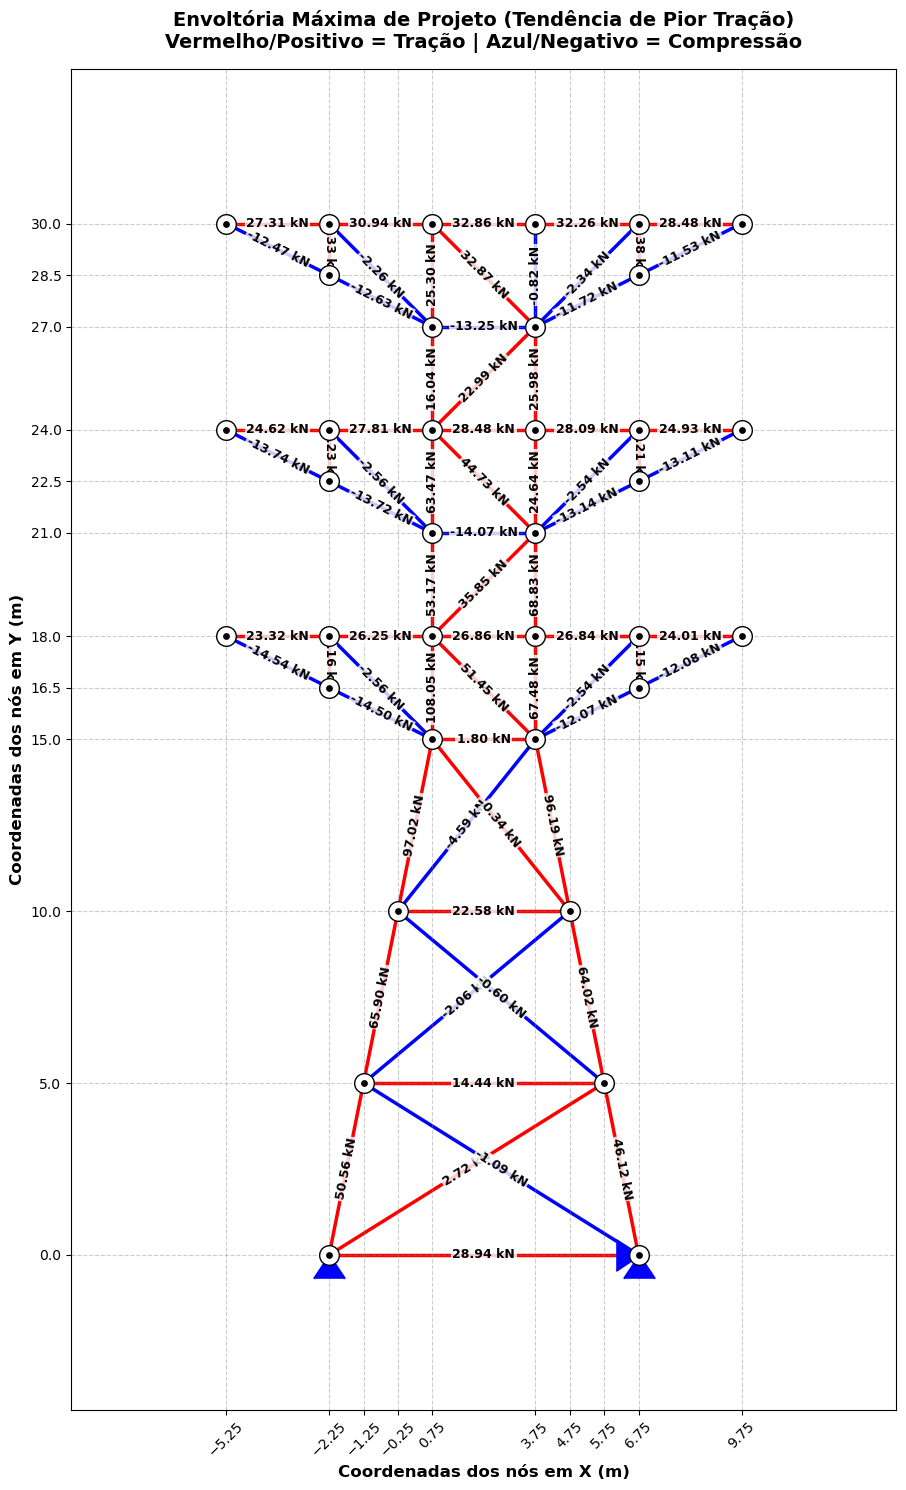

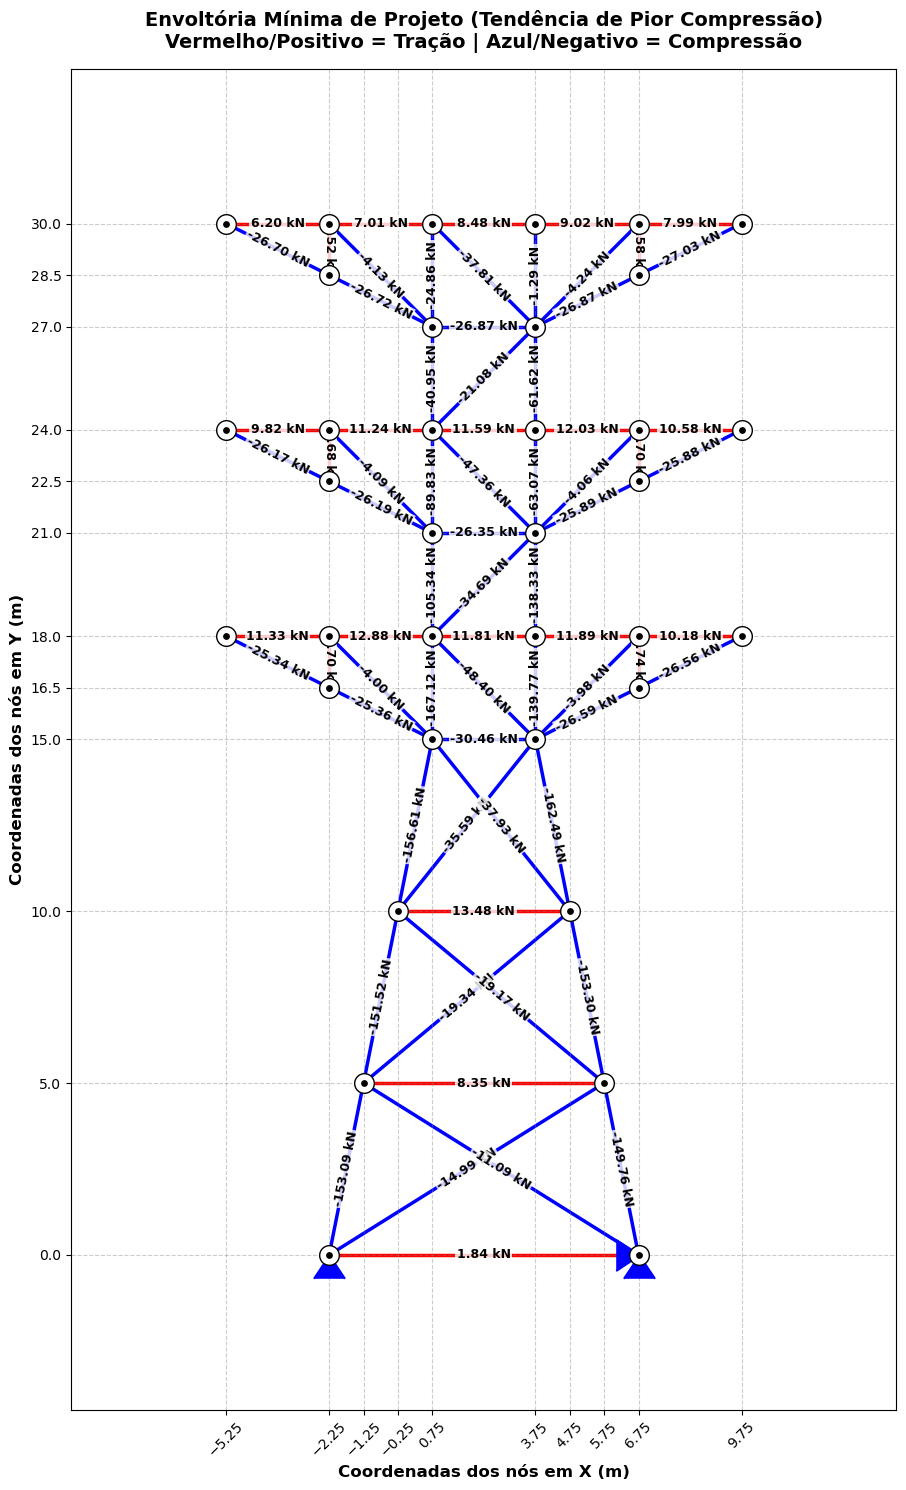

In [29]:
# Extração Envoltórias Pior Cenário Global (Tração e Compressão Absolutas)
df_combos['Env. Máxima (kN)'] = df_combos[['Comb. X (Máx)', 'Comb. Y (Máx)', 'Comb. 45° (Máx)']].max(axis=1)
df_combos['Env. Mínima (kN)'] = df_combos[['Comb. X (Mín)', 'Comb. Y (Mín)', 'Comb. 45° (Mín)']].min(axis=1)

def plotar_envoltoria(coluna_alvo, titulo_grafico):
    plt.figure(figsize=(15, 15))
    plt.title(f'{titulo_grafico}\nVermelho/Positivo = Tração | Azul/Negativo = Compressão', 
              fontsize=14, weight='bold', pad=15)

    for idx, row in df_combos.iterrows(): 
        ni, nf = int(row['Nó Inicial']), int(row['Nó Final'])
        esf_val = row[coluna_alvo]
        
        xi, yi = nos.loc[ni, ['X', 'Y']]
        xf, yf = nos.loc[nf, ['X', 'Y']]
        
        dy, dx = yf - yi, xf - xi
        ANG = np.degrees(np.arctan2(dy, dx))
        if ANG > 90:
            ANG -= 180
        elif ANG < -90:
            ANG += 180
        
        if abs(esf_val) < 1e-4:
            cor = 'k' 
        elif esf_val > 0:
            cor = 'r' 
        else: 
            cor = 'b' 
            
        plt.plot([xi, xf], [yi, yf], color=cor, zorder=1, linewidth=2.5)

        plt.text(np.mean([xi, xf]), np.mean([yi, yf]),
                 f'{esf_val:.2f} kN',
                 rotation=ANG,
                 horizontalalignment='center',
                 verticalalignment='center',
                 size=9,
                 weight='bold',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1),
                 zorder=2)
    
    for row in nos.itertuples(): 
        X, Y, RX, RY = row.X, row.Y, row.RX, row.RY
        plt.scatter(X, Y, s=200, c='white', edgecolors='black', marker='o', zorder=3)
        plt.scatter(X, Y, s=15, c='black', marker='o', zorder=4)
        if RX == 1: plt.scatter(X, Y, s=500, color='blue', marker=5, zorder=2) 
        if RY == 1: plt.scatter(X, Y, s=500, color='blue', marker=6, zorder=2) 

    coordenadas_x = nos['X'].unique()
    coordenadas_y = nos['Y'].unique()
    plt.xlabel('Coordenadas dos nós em X (m)', fontsize=12, weight='bold')
    plt.ylabel('Coordenadas dos nós em Y (m)', fontsize=12, weight='bold')
    plt.xticks(coordenadas_x, rotation=45)
    plt.yticks(coordenadas_y)
    plt.grid(visible=True, which='major', color='gray', linestyle='--', alpha=0.4, zorder=-2)

    dim_ref = max(nos['X'].max() - nos['X'].min(), nos['Y'].max() - nos['Y'].min())
    if dim_ref == 0: dim_ref = 1.0
    margem = dim_ref * 0.15
    plt.xlim(coordenadas_x.min() - margem, coordenadas_x.max() + margem)
    plt.ylim(coordenadas_y.min() - margem, coordenadas_y.max() + margem)
    plt.gca().set_aspect('equal')
    plt.tight_layout() 
    plt.show()

plotar_envoltoria('Env. Máxima (kN)', 'Envoltória Máxima de Projeto (Tendência de Pior Tração)')
plotar_envoltoria('Env. Mínima (kN)', 'Envoltória Mínima de Projeto (Tendência de Pior Compressão)')

### SÍNTESE DAS REAÇÕES DE APOIO E ENVOLTÓRIAS PARA FUNDAÇÃO

Como nenhum cálculo estrutural está pronto até as fundações receberem as cargas absolutas, nós montamos uma envoltória exclusiva para o repasse à infraestrutura (dimensionamento das sapatas, estacas e chumbadores).

Nós superpomos a parcela estática gravitacional com os ciclos da Matriz de Rigidez Dinâmica multiplicada pelo deslocamento do tempo. 

**Diretrizes de Interpretação para Projeto:**
* **Cortante na Base (*Base Shear*):** A demanda bruta em X para dimensionamento dos chumbadores contra cisalhamento.
* **Esforços de Compressão:** Esforços máximos atuantes em +Y regendo carga admissível e punção em sapatas.
* **Arrancamento (*Uplift*):** A temida inversão de sinal (em **negativo**) na envoltória de Mínima Y, sinalizando a obrigatoriedade de tirantes e chumbadores resistentes à tração elástica.

In [30]:
# Mapeamento dos graus de liberdade (GDL) com restrição (Apoios)
gdl_apoios = []
nomes_apoios = []

for row in nos.itertuples():
    if row.RX == 1:
        gdl_apoios.append(2 * row.Index - 2)
        nomes_apoios.append(f"Nó {row.Index} - X")
    if row.RY == 1:
        gdl_apoios.append(2 * row.Index - 1)
        nomes_apoios.append(f"Nó {row.Index} - Y")

reacoes_est = []
max_X, min_X = [], []
max_Y, min_Y = [], []
max_45, min_45 = [], []
env_max, env_min = [], []

# Superposição de efeitos no domínio do tempo para cada GDL restrito
for gdl in gdl_apoios:
    # 1. Isolar a reação estática para este grau de liberdade (R já foi calculado antes)
    r_est = R[gdl] / 1000.0  # Converte de N para kN
    reacoes_est.append(r_est)
    
    # Linha da Matriz de Rigidez associada a este GDL
    K_linha = Kg[gdl, :]
    
    # 2. Cenário: Sismo em X
    R_din_t_X = np.dot(K_linha, U_X) / 1000.0
    R_tot_X = r_est + R_din_t_X
    max_X.append(np.max(R_tot_X))
    min_X.append(np.min(R_tot_X))
    
    # 3. Cenário: Sismo em Y
    R_din_t_Y = np.dot(K_linha, U_Y) / 1000.0
    R_tot_Y = r_est + R_din_t_Y
    max_Y.append(np.max(R_tot_Y))
    min_Y.append(np.min(R_tot_Y))
    
    # 4. Cenário: Sismo a 45°
    R_din_t_45 = np.dot(K_linha, U_45) / 1000.0
    R_tot_45 = r_est + R_din_t_45
    max_45.append(np.max(R_tot_45))
    min_45.append(np.min(R_tot_45))
    
    # 5. Envoltórias Absolutas de Projeto
    env_max.append(max([max_X[-1], max_Y[-1], max_45[-1]]))
    env_min.append(min([min_X[-1], min_Y[-1], min_45[-1]]))

# Consolidando em um DataFrame para o Calculista
df_reacoes_finais = pd.DataFrame({
    'Apoio - GDL': nomes_apoios,
    'Estática (kN)': reacoes_est,
    'Sismo X (Máx)': max_X,
    'Sismo X (Mín)': min_X,
    'Sismo Y (Máx)': max_Y,
    'Sismo Y (Mín)': min_Y,
    'Sismo 45° (Máx)': max_45,
    'Sismo 45° (Mín)': min_45,
    'ENV. MÁX (kN)': env_max,
    'ENV. MÍN (kN)': env_min
})

def formatar_tabela_reacoes(val):
    if isinstance(val, (int, float)):
        # Alerta de Arrancamento/Tração na fundação (Valores negativos)
        if val < -1e-4:
            return 'color: #d62728; font-weight: bold;'
    return 'color: black;'

colunas_formato = ['Estática (kN)', 'Sismo X (Máx)', 'Sismo X (Mín)', 
                   'Sismo Y (Máx)', 'Sismo Y (Mín)', 'Sismo 45° (Máx)', 
                   'Sismo 45° (Mín)', 'ENV. MÁX (kN)', 'ENV. MÍN (kN)']

print("\nTABELA SÍNTESE DE REAÇÕES DE APOIO E ENVOLTÓRIAS DE FUNDAÇÃO (kN)\n")
print("-> Cores em vermelho indicam reações negativas (Atenção para ocorrência de Arrancamento em Y)")
display(df_reacoes_finais.style.hide(axis="index")
                         .map(formatar_tabela_reacoes, subset=colunas_formato)
                         .format("{:.2f}", subset=colunas_formato)
                         .set_properties(subset=['ENV. MÁX (kN)', 'ENV. MÍN (kN)'], 
                                         **{'background-color': '#f2f2f2', 'font-weight': 'bold'}))


TABELA SÍNTESE DE REAÇÕES DE APOIO E ENVOLTÓRIAS DE FUNDAÇÃO (kN)

-> Cores em vermelho indicam reações negativas (Atenção para ocorrência de Arrancamento em Y)


Apoio - GDL,Estática (kN),Sismo X (Máx),Sismo X (Mín),Sismo Y (Máx),Sismo Y (Mín),Sismo 45° (Máx),Sismo 45° (Mín),ENV. MÁX (kN),ENV. MÍN (kN)
Nó 16 - X,-0.00,32.36,-30.54,1.62,-1.61,23.40,-21.75,32.36,-30.54
Nó 16 - Y,56.21,150.74,-38.35,71.12,43.72,122.88,-11.85,150.74,-38.35
Nó 17 - Y,56.21,151.49,-38.93,70.08,43.57,126.18,-12.42,151.49,-38.93
